# Dyck-(2,3) CFG next-token results and probes (50% noise, len 80-120)

This notebook trains or loads the Dyck-(2,3) CFG next-token runs with planted noise, restricted to the `len_80_120` length bin. It keeps the same probe layout as the no-noise notebook: fixed-prefix probes, stack/top-of-stack probes, PCA views, supervised projection views, prefix sweeps, and direction arithmetic. Missing artifacts are generated automatically; set `RUN_TRAINING = True` to intentionally retrain the 4 runs.


In [1]:
from pathlib import Path
import json
import sys

ROOT = Path.cwd()
if ROOT.name == 'notebooks':
    ROOT = ROOT.parent
SRC = ROOT / 'src'
if str(SRC) not in sys.path:
    sys.path.insert(0, str(SRC))

import numpy as np
import pandas as pd
import torch
import matplotlib.pyplot as plt

try:
    from sklearn.decomposition import PCA
except Exception:
    PCA = None

from hse.analysis.probes.linear import extract_linear_weight, fit_logistic_probe, fit_ridge_probe
from hse.experiments.dyck23 import DYCK23_LENGTH_BINS, DYCK23_MODEL_SPECS, run_dyck23_suite
from hse.tasks.dyck23 import Dyck23Config, Dyck23Sampler, validate_dyck23_tokens
from hse.utils.labels_io import load_labels


/home/hp_twist_shan/miniforge3/envs/hse/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [2]:
EXPERIMENT_NAME = 'dyck23_cfg_next_token_50_noise_len_80_120'
RESULTS_ROOT = ROOT / 'results' / EXPERIMENT_NAME
FIGURES_ROOT = RESULTS_ROOT / 'figures'
FIGURES_ROOT.mkdir(parents=True, exist_ok=True)

MODEL_TYPES = ['rnn', 'lstm', 'transformer', 'mamba']
SEED = 0
DEVICE = 'cuda' if torch.cuda.is_available() else 'cpu'

RUN_TRAINING = False  # Missing artifacts auto-train; set True to intentionally retrain all 4 runs.
TRAIN_EXAMPLES = 10_000
TEST_EXAMPLES = 2_000
PROBE_EXAMPLES = 1_024
TRAINING_STEPS = 15_000
EPOCHS = 20
BATCH_SIZE = 128
MAX_PROBE_ROWS = 20_000

NOISE_GENERATION_PROB = 0.5
NUM_NOISE_TOKENS = 10
PROBE_DYCK_POSITIONS_ONLY = True

DYCK23_LENGTH_BINS = {
    'len_80_120': {
        'min_length': 80,
        'max_length': 120,
        'generation_prob': NOISE_GENERATION_PROB,
        'num_noise_tokens': NUM_NOISE_TOKENS,
    },
}

BALANCE_PROBE_BY = 'depth_top_class'
PROBE_MIN_CLASS_COUNT = 8
PROBE_MAX_PER_CLASS = 128
PCA_MAX_POINTS = 5_000

RIDGE_TARGETS = [
    'left', 'right', 'height',
    'left_round', 'right_round', 'height_round',
    'left_square', 'right_square', 'height_square',
]
CLASS_TARGETS = ['top_type_class', 'depth_top_class', 'legal_next_class', 'height_class']
COUNTER_TARGET_PAIRS = [
    ('height_round', 'height_square'),
    ('left_round', 'left_square'),
    ('right_round', 'right_square'),
]
GRID_TARGET_PAIRS = [
    ('height_round', 'height_square'),
    ('left_round', 'left_square'),
]
COUNTER_TOTAL_TARGETS = {
    ('height_round', 'height_square'): 'height',
    ('left_round', 'left_square'): 'left',
    ('right_round', 'right_square'): 'right',
}

FIXED_PREFIX_BY_BIN = {
    'len_80_120': 100,
}
SWEEP_PREFIX_BY_BIN = {
    'len_80_120': list(range(84, 121, 4)),
}

pd.DataFrame([
    {'model': name, **{k: v for k, v in spec.items() if k != 'state_kind'}}
    for name, spec in DYCK23_MODEL_SPECS.items()
])


,model,layers,emb_dim,hidden_dim,dropout,learned_initial_state,fused,n_heads,ffn_dim,pos_encoding,embed_scale,final_layer_norm,state_dim,expansion_factor,require_official_mamba
0,rnn,5,80,80,0.1,True,True,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,lstm,5,40,40,0.1,True,True,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,transformer,5,32,32,0.1,NaN,NaN,8.0,128.0,sinusoidal,True,True,NaN,NaN,NaN
3,mamba,5,36,36,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,16.0,2.0,True


整个 notebook 的全局设置：4 个模型、50% planted noise、`len_80_120`、是否重新训练、15k training steps、固定 prefix、prefix sweep，以及后面要 probe 的 regression/classification target。展示 4 个模型的结构参数表。

这一组配置是一个比较强的 planted-noise stress test：只跑 `len_80_120`，bracket 长度 80-120；`generation_prob = 0.5` 会把 payload 拉到约 160-240，因此有效 target 里大约 49.75% 是 bracket、49.75% 是随机 noise、0.5% 是 EOS。词表大小是 17：`0/1/2` 是 PAD/BOS/EOS，`3..12` 是 10 个 noise token，`13..16` 是两类括号。

后面所有 overall next-token accuracy 都不能和 no-noise 版本直接比；它混入了大量不可预测的随机 noise target。更应该同时看 `dyck_accuracy` 和 probe 读出结果。


## 1. Load the 4 trained noise runs

The checkpoints, hidden states, labels, and probe summaries live under `results/dyck23_cfg_next_token_50_noise_len_80_120`. This cell reads those artifacts when present, generates them when missing, and retrains them only when `RUN_TRAINING = True`.


In [3]:
runs_path = RESULTS_ROOT / 'runs.csv'
probe_path = RESULTS_ROOT / 'probe_summary.csv'

should_train = RUN_TRAINING or not (runs_path.exists() and probe_path.exists())

if should_train:
    runs_df, probe_df = run_dyck23_suite(
        seed=SEED,
        models=MODEL_TYPES,
        length_bins=DYCK23_LENGTH_BINS,
        train_examples=TRAIN_EXAMPLES,
        test_examples=TEST_EXAMPLES,
        probe_examples=PROBE_EXAMPLES,
        steps=TRAINING_STEPS,
        epochs=EPOCHS,
        batch_size=BATCH_SIZE,
        max_probe_rows=MAX_PROBE_ROWS,
        device=DEVICE,
        results_root=RESULTS_ROOT,
        setting_name=EXPERIMENT_NAME,
    )
else:
    runs_df = pd.read_csv(runs_path)
    probe_df = pd.read_csv(probe_path)

expected_runs = len(MODEL_TYPES) * len(DYCK23_LENGTH_BINS)

if len(runs_df) != expected_runs or len(probe_df) != expected_runs:
    run_rows = []
    probe_rows = []
    for length_bin in DYCK23_LENGTH_BINS:
        for model_type in MODEL_TYPES:
            run_dir = RESULTS_ROOT / length_bin / f'{model_type}_seed{SEED}'
            config_path = run_dir / 'config.json'
            metrics_path = run_dir / 'metrics.json'
            if not config_path.exists() or not metrics_path.exists():
                raise FileNotFoundError(f'Missing completed artifacts under {run_dir}')
            config = json.load(open(config_path))
            metrics = json.load(open(metrics_path))
            labels_path = run_dir / 'labels.parquet'
            if labels_path.exists():
                hidden_rows = len(pd.read_parquet(labels_path, columns=['example_id']))
            else:
                hidden_rows = len(pd.read_csv(run_dir / 'labels.csv', usecols=['example_id']))
            eval_metrics = metrics['eval']
            hidden_dim = int(config['model'].get('hidden_dim', config['model'].get('emb_dim')))
            run_rows.append({
                'length_bin': length_bin,
                'model': model_type,
                'seed': config['seed'],
                'run_dir': str(run_dir.resolve()),
                'loss': eval_metrics['loss'],
                'accuracy': eval_metrics['accuracy'],
                'dyck_accuracy': eval_metrics['dyck_accuracy'],
                'hidden_rows': hidden_rows,
                'hidden_dim': hidden_dim,
                'params': config['trainable_parameters'],
                'backbone_params': config['backbone_parameters_excluding_lm_head'],
                'elapsed_seconds': metrics.get('elapsed_seconds'),
            })
            probe_rows.append({
                'length_bin': length_bin,
                'model': model_type,
                'seed': config['seed'],
                **metrics.get('probe', {}),
                **metrics.get('compression', {}),
            })
    runs_df = pd.DataFrame(run_rows)
    probe_df = pd.DataFrame(probe_rows)
    runs_df.to_csv(runs_path, index=False)
    probe_df.to_csv(probe_path, index=False)

if len(runs_df) != expected_runs or len(probe_df) != expected_runs:
    raise ValueError(f'Expected {expected_runs} runs/probe rows, got {len(runs_df)} and {len(probe_df)}.')

runs_df.sort_values(['length_bin', 'model']).reset_index(drop=True)


,length_bin,model,seed,run_dir,loss,accuracy,dyck_accuracy,hidden_rows,hidden_dim,params,backbone_params,elapsed_seconds
0,len_80_120,lstm,0,/home/hp_twist_shan/Research/Hidden State Eval...,2.259910,0.286328,0.571886,205624,40,67177,66480,205.190669
1,len_80_120,mamba,0,/home/hp_twist_shan/Research/Hidden State Eval...,2.258381,0.286201,0.571871,205624,36,62081,61452,438.979418
2,len_80_120,rnn,0,/home/hp_twist_shan/Research/Hidden State Eval...,2.270412,0.285481,0.573831,205624,80,67937,66560,198.471069
3,len_80_120,transformer,0,/home/hp_twist_shan/Research/Hidden State Eval...,2.254868,0.286953,0.569896,205624,32,64689,64128,1743.415038


即 1 个长度桶 × 4 个模型。主要看 `loss`、`accuracy`、`dyck_accuracy`、`backbone_params` 和 `elapsed_seconds`。

accuracy: 所有有效 target token 上的 next-token accuracy = noise tokens + bracket tokens + EOS
dyck_accuracy: 只在 Dyck bracket token 上的 next-token accuracy = 只算 ( ) [ ]


这里 overall `accuracy` 只有约 0.285-0.287，看起来很低，但主要原因是 **noise target 是 iid 随机离散 token**。模型没有可用上下文去精确预测下一个随机 noise token；用 overall/dyck 分解反推，非-Dyck target 的 exact-match accuracy 基本只有 0-0.7%。

更有解释性的 `dyck_accuracy` 约 0.57，表示模型在目标 token 是括号时的预测水平。由于有效 target 中 bracket 和 noise 各约一半，所以 overall accuracy 近似被压成 `0.5 * dyck_accuracy + 0.5 * noise_accuracy`，也就是约 0.286。低 overall accuracy 不等于模型没有学到 stack state；后面的 probe 结果反而显示 hidden state 里有很强的 Dyck 状态信息。


## 2. Load saved probe arrays

The suite saves one row per valid next-token prediction position. For a fixed-prefix view, filter by `dyck_seen`, then balance by `depth_top_class` as in the Dyck-k long notebook.

In [4]:
def load_run_arrays(run_dir):
    run_dir = Path(run_dir)
    if not run_dir.is_absolute():
        candidates = [ROOT / run_dir, RESULTS_ROOT / run_dir]
        run_dir = next((path for path in candidates if (path / 'hidden_states.pt').exists()), ROOT / run_dir)
    hidden_path = run_dir / 'hidden_states.pt'
    if not hidden_path.exists():
        raise FileNotFoundError(f'Missing hidden states at {hidden_path}')
    hidden = torch.load(hidden_path, map_location='cpu').numpy()
    labels_path = run_dir / 'labels.parquet'
    if not labels_path.exists():
        labels_path = run_dir / 'labels.csv'
    labels = load_labels(labels_path)
    if PROBE_DYCK_POSITIONS_ONLY and 'is_dyck_position' in labels:
        dyck_pos = labels['is_dyck_position'].to_numpy(dtype=bool)
        hidden = hidden[dyck_pos]
        labels = labels.loc[dyck_pos].reset_index(drop=True)
    return {'X': hidden, 'labels': labels, 'run_dir': run_dir}


def select_prefix(data, prefix):
    labels = data['labels']
    mask = labels['dyck_seen'].to_numpy() == int(prefix)
    return {'X': data['X'][mask], 'labels': labels.loc[mask].reset_index(drop=True), 'run_dir': data['run_dir']}


def balance_data_by_label(data, label=BALANCE_PROBE_BY, seed=0, max_per_class=PROBE_MAX_PER_CLASS, min_per_class=PROBE_MIN_CLASS_COUNT):
    labels = data['labels']
    rng = np.random.default_rng(seed)
    chosen = []
    for _, idx in labels.groupby(label).indices.items():
        idx = np.asarray(idx)
        if len(idx) < min_per_class:
            continue
        take = min(len(idx), max_per_class) if max_per_class else len(idx)
        chosen.append(rng.choice(idx, size=take, replace=False))
    if not chosen:
        return data
    chosen = np.sort(np.concatenate(chosen))
    return {'X': data['X'][chosen], 'labels': labels.iloc[chosen].reset_index(drop=True), 'run_dir': data['run_dir']}


def print_class_balance(data, label=BALANCE_PROBE_BY, name='data', limit=12):
    counts = data['labels'][label].value_counts().sort_index()
    preview = ', '.join(f'{k}:{v}' for k, v in counts.head(limit).items())
    print(f'{name} {label} counts -> {preview}')


run_arrays = {
    (row.length_bin, row.model): load_run_arrays(row.run_dir)
    for row in runs_df.itertuples()
}


In [5]:
def _split_indices(n, seed=0, test_size=0.25):
    rng = np.random.default_rng(seed)
    idx = rng.permutation(n)
    n_test = max(1, int(round(n * test_size)))
    return idx[n_test:], idx[:n_test]


def _standardize_train_test(X_train, X_test):
    mean = X_train.mean(axis=0, keepdims=True)
    std = X_train.std(axis=0, keepdims=True)
    std[std < 1e-8] = 1.0
    return (X_train - mean) / std, (X_test - mean) / std, mean, std


def _r2_score_np(y_true, y_pred):
    ss_res = float(((y_true - y_pred) ** 2).sum())
    ss_tot = float(((y_true - y_true.mean()) ** 2).sum())
    return 1.0 - ss_res / (ss_tot + 1e-12)


def fit_ridge_train_test(X_train, y_train, X_test, y_test, name, alpha=1.0):
    X_train = np.asarray(X_train, dtype=np.float64)
    X_test = np.asarray(X_test, dtype=np.float64)
    y_train = np.asarray(y_train, dtype=np.float64)
    y_test = np.asarray(y_test, dtype=np.float64)
    X_train_s, X_test_s, mean, std = _standardize_train_test(X_train, X_test)
    X_aug = np.concatenate([X_train_s, np.ones((len(X_train_s), 1))], axis=1)
    eye = np.eye(X_aug.shape[1])
    eye[-1, -1] = 0.0
    system = X_aug.T @ X_aug + alpha * eye
    rhs = X_aug.T @ y_train
    try:
        coef_aug = np.linalg.solve(system, rhs)
    except np.linalg.LinAlgError:
        coef_aug = np.linalg.pinv(system) @ rhs
    pred = np.concatenate([X_test_s, np.ones((len(X_test_s), 1))], axis=1) @ coef_aug
    coef = coef_aug[:-1] / std.squeeze()
    intercept = float(coef_aug[-1] - (mean.squeeze() / std.squeeze()) @ coef_aug[:-1])
    return {'name': name, 'probe': {'coef': coef, 'intercept': intercept}, 'r2': float(_r2_score_np(y_test, pred)), 'mae': float(np.abs(y_test - pred).mean())}


def _shared_class_subset(X_train, y_train, X_test, y_test, min_count=2):
    train_counts = pd.Series(y_train).value_counts()
    test_counts = pd.Series(y_test).value_counts()
    keep = np.intersect1d(
        train_counts[train_counts >= min_count].index.to_numpy(),
        test_counts[test_counts >= min_count].index.to_numpy(),
    )
    train_mask = np.isin(y_train, keep)
    test_mask = np.isin(y_test, keep)
    return X_train[train_mask], y_train[train_mask], X_test[test_mask], y_test[test_mask]


def fit_logistic_train_test(X_train, y_train, X_test, y_test, name):
    X_train = np.asarray(X_train, dtype=np.float32)
    X_test = np.asarray(X_test, dtype=np.float32)
    y_train = np.asarray(y_train)
    y_test = np.asarray(y_test)
    X_train, y_train, X_test, y_test = _shared_class_subset(X_train, y_train, X_test, y_test)
    classes = np.unique(y_train)
    if len(classes) < 2 or len(X_test) == 0:
        return {'name': name, 'probe': None, 'accuracy': float('nan'), 'n_classes': int(len(classes))}
    class_to_idx = {cls: idx for idx, cls in enumerate(classes)}
    y_train_idx = np.array([class_to_idx[v] for v in y_train], dtype=np.int64)
    y_test_idx = np.array([class_to_idx[v] for v in y_test], dtype=np.int64)
    X_train_s, X_test_s, _, std = _standardize_train_test(X_train, X_test)
    model = torch.nn.Linear(X_train_s.shape[1], len(classes))
    opt = torch.optim.LBFGS(model.parameters(), lr=0.5, max_iter=100)
    loss_fn = torch.nn.CrossEntropyLoss()
    X_train_t = torch.tensor(X_train_s, dtype=torch.float32)
    y_train_t = torch.tensor(y_train_idx, dtype=torch.long)

    def closure():
        opt.zero_grad()
        loss = loss_fn(model(X_train_t), y_train_t)
        loss.backward()
        return loss

    opt.step(closure)
    with torch.no_grad():
        pred = model(torch.tensor(X_test_s, dtype=torch.float32)).argmax(dim=-1).numpy()
    coef = model.weight.detach().numpy() / std.squeeze()[None, :]
    return {'name': name, 'probe': {'coef': coef, 'classes': classes}, 'accuracy': float((pred == y_test_idx).mean()), 'n_classes': int(len(classes))}


def run_stack_probes(data, seed=0):
    X = data['X']
    labels = data['labels']
    train_idx, test_idx = _split_indices(len(labels), seed=seed)
    fitted = {}
    rows = []

    for target in RIDGE_TARGETS:
        if target not in labels:
            continue
        result = fit_ridge_train_test(X[train_idx], labels[target].to_numpy()[train_idx], X[test_idx], labels[target].to_numpy()[test_idx], target)
        fitted[f'ridge_{target}'] = result
        rows.append({'probe_type': 'ridge', 'target': target, 'r2': result['r2'], 'mae': result['mae']})

    for target in CLASS_TARGETS:
        if target not in labels or labels[target].nunique() <= 1:
            continue
        y = labels[target].to_numpy()
        result = fit_logistic_train_test(X[train_idx], y[train_idx], X[test_idx], y[test_idx], target)
        fitted[f'logistic_{target}'] = result
        rows.append({'probe_type': 'logistic', 'target': target, 'accuracy': result['accuracy'], 'n_classes': labels[target].nunique()})
    return fitted, pd.DataFrame(rows)


fixed_probe_results = {}
fixed_probe_rows = []
for length_bin in DYCK23_LENGTH_BINS:
    prefix = FIXED_PREFIX_BY_BIN[length_bin]
    for model_type in MODEL_TYPES:
        raw = select_prefix(run_arrays[(length_bin, model_type)], prefix)
        balanced = balance_data_by_label(raw, seed=SEED)
        print_class_balance(balanced, name=f'{length_bin} {model_type} prefix={prefix}')
        fitted, table = run_stack_probes(balanced, seed=SEED)
        fixed_probe_results[(length_bin, model_type)] = {'data': balanced, 'fitted': fitted, 'table': table, 'prefix': prefix}
        for row in table.to_dict('records'):
            fixed_probe_rows.append({'length_bin': length_bin, 'model': model_type, 'prefix': prefix, **row})

fixed_probe_df = pd.DataFrame(fixed_probe_rows)
fixed_probe_df.to_csv(RESULTS_ROOT / 'fixed_prefix_probe_summary.csv', index=False)
fixed_probe_df


len_80_120 rnn prefix=100 depth_top_class counts -> 0:128, 7:128, 8:128
len_80_120 lstm prefix=100 depth_top_class counts -> 0:128, 7:128, 8:128
len_80_120 transformer prefix=100 depth_top_class counts -> 0:128, 7:128, 8:128
len_80_120 mamba prefix=100 depth_top_class counts -> 0:128, 7:128, 8:128


,length_bin,model,prefix,probe_type,target,r2,mae,accuracy,n_classes
0,len_80_120,rnn,100,ridge,left,0.999975,0.001681,NaN,NaN
1,len_80_120,rnn,100,ridge,right,0.999975,0.001681,NaN,NaN
2,len_80_120,rnn,100,ridge,height,0.999975,0.003362,NaN,NaN
3,len_80_120,rnn,100,ridge,left_round,-0.103996,2.987250,NaN,NaN
4,len_80_120,rnn,100,ridge,right_round,-0.054858,2.995959,NaN,NaN
5,len_80_120,rnn,100,ridge,height_round,0.978768,0.062555,NaN,NaN
6,len_80_120,rnn,100,ridge,left_square,-0.041704,2.988060,NaN,NaN
7,len_80_120,rnn,100,ridge,right_square,-0.114734,2.995148,NaN,NaN
8,len_80_120,rnn,100,ridge,height_square,0.981407,0.062530,NaN,NaN
9,len_80_120,rnn,100,logistic,top_type_class,NaN,NaN,1.000000,3.0


固定 prefix=100 的 probe 很强：`height`、`top_type_class`、`depth_top_class` 基本都是 1.0，说明四个模型都能从 hidden state 中线性/逻辑读出当前栈深和栈顶。`legal_next_class` 在 0.77-0.865，比 depth/top 低，说明“下一步动作集合/终止预算”比单纯 stack state 更难读。

注意固定 prefix 下 `left_round`/`left_square` 这类累计 open counter 的 R2 很差，甚至为负；这不是简单地说模型完全不知道类型，而是因为固定 prefix 强约束了两个类型 counter 的 trade-off，raw cumulative direction 在这个切片上不稳定。相比之下 `height_round`/`height_square` 仍然可读，RNN/Transformer 最清楚，LSTM/Mamba 稍弱。


## 3. PCA views and same-counter stack slices

saved figure -> /home/hp_twist_shan/Research/Hidden State Evaluation/results/dyck23_cfg_next_token_50_noise_len_80_120/figures/pca/len_80_120_rnn_pca.png


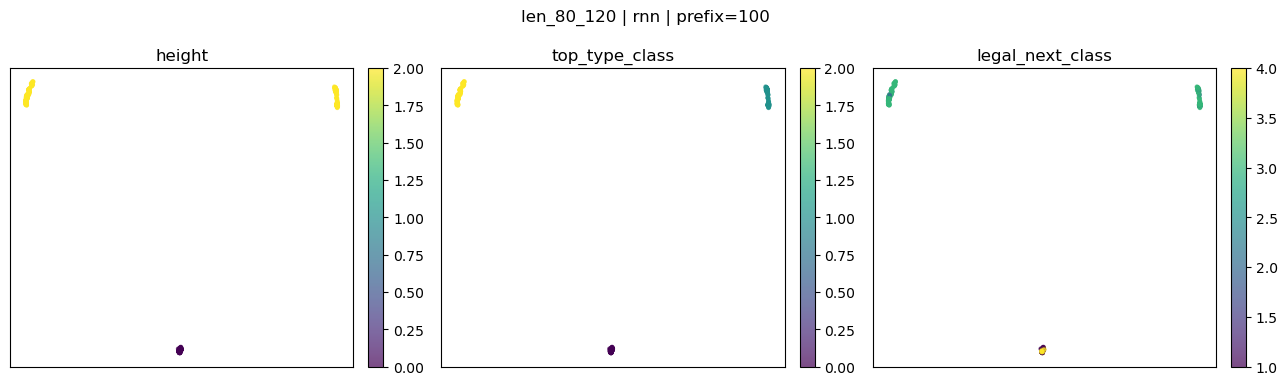

saved figure -> /home/hp_twist_shan/Research/Hidden State Evaluation/results/dyck23_cfg_next_token_50_noise_len_80_120/figures/stack_slices/len_80_120_rnn_same_counters_diff_stack.png


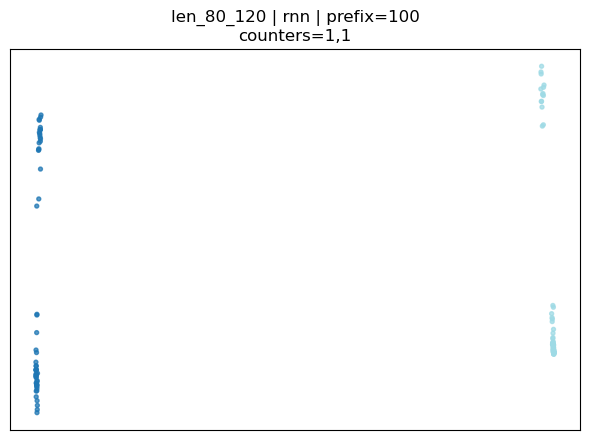

saved figure -> /home/hp_twist_shan/Research/Hidden State Evaluation/results/dyck23_cfg_next_token_50_noise_len_80_120/figures/pca/len_80_120_lstm_pca.png


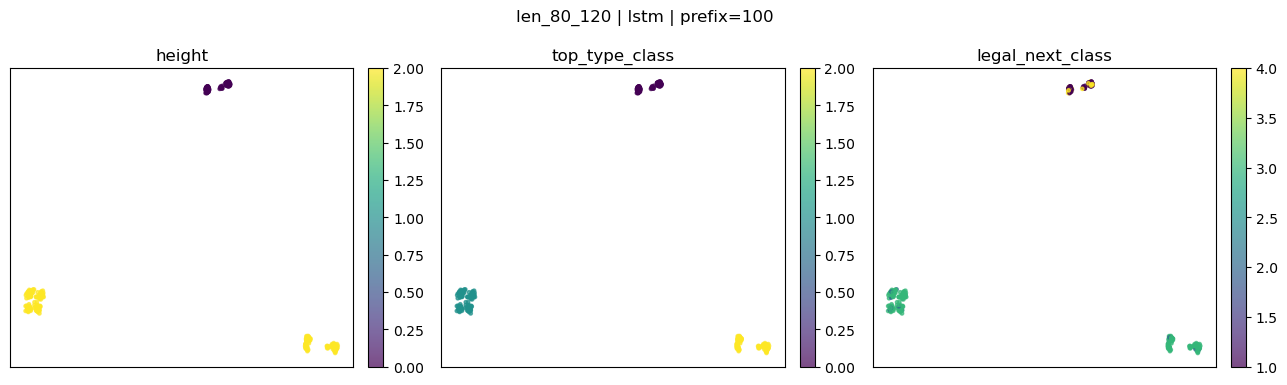

saved figure -> /home/hp_twist_shan/Research/Hidden State Evaluation/results/dyck23_cfg_next_token_50_noise_len_80_120/figures/stack_slices/len_80_120_lstm_same_counters_diff_stack.png


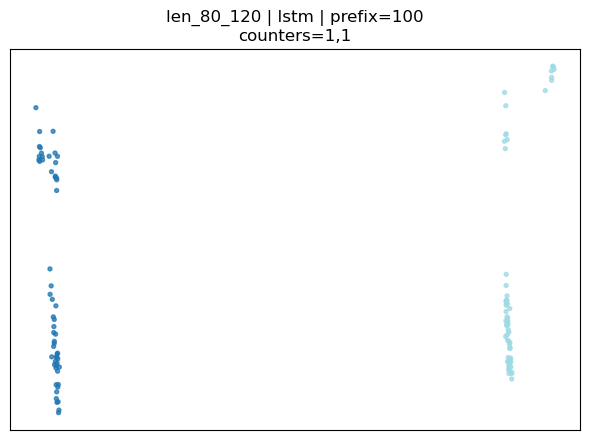

saved figure -> /home/hp_twist_shan/Research/Hidden State Evaluation/results/dyck23_cfg_next_token_50_noise_len_80_120/figures/pca/len_80_120_transformer_pca.png


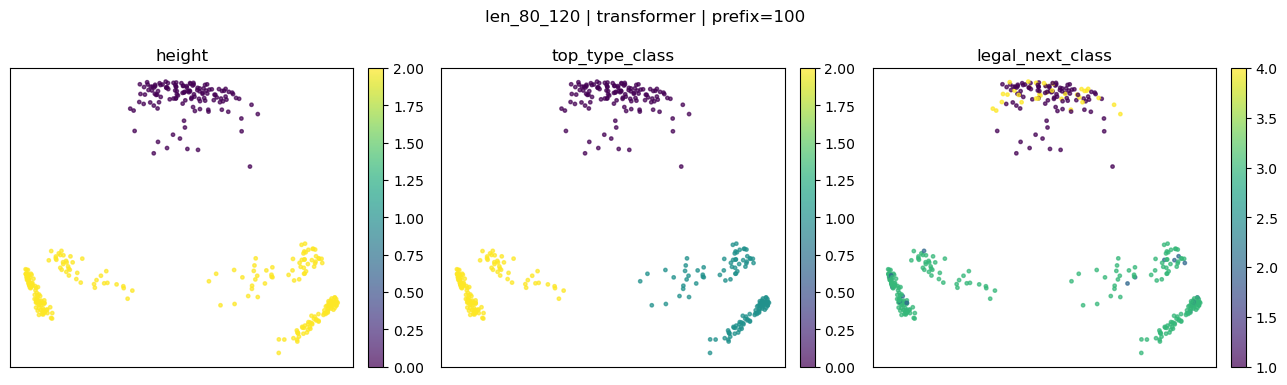

saved figure -> /home/hp_twist_shan/Research/Hidden State Evaluation/results/dyck23_cfg_next_token_50_noise_len_80_120/figures/stack_slices/len_80_120_transformer_same_counters_diff_stack.png


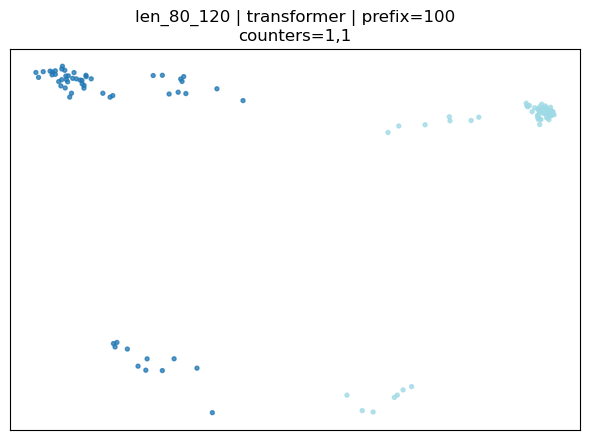

saved figure -> /home/hp_twist_shan/Research/Hidden State Evaluation/results/dyck23_cfg_next_token_50_noise_len_80_120/figures/pca/len_80_120_mamba_pca.png


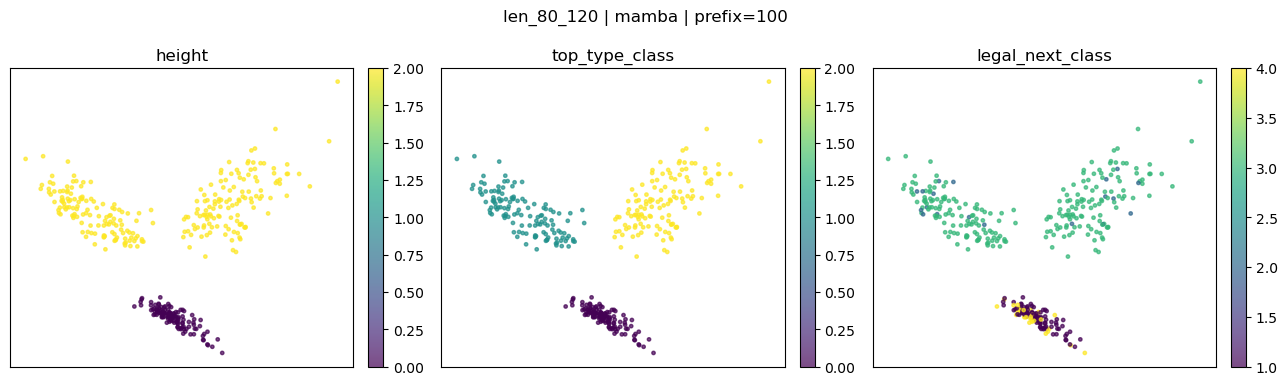

saved figure -> /home/hp_twist_shan/Research/Hidden State Evaluation/results/dyck23_cfg_next_token_50_noise_len_80_120/figures/stack_slices/len_80_120_mamba_same_counters_diff_stack.png


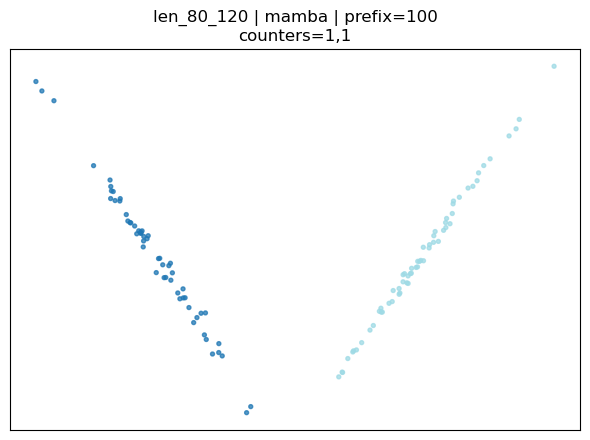

In [6]:
def pca_2d(X):
    X = np.asarray(X, dtype=np.float64)
    X = X - X.mean(axis=0, keepdims=True)
    if PCA is not None:
        return PCA(n_components=2).fit_transform(X)
    _, _, vt = np.linalg.svd(X, full_matrices=False)
    return X @ vt[:2].T


def finalize_figure(fig, section, stem):
    out_dir = FIGURES_ROOT / section
    out_dir.mkdir(parents=True, exist_ok=True)
    out_path = out_dir / f'{stem}.png'
    fig.tight_layout()
    fig.savefig(out_path, dpi=150, bbox_inches='tight')
    print(f'saved figure -> {out_path}')


def plot_depth_counter_pca_panels(result, title, save_stem, max_points=PCA_MAX_POINTS):
    data = result['data']
    labels = data['labels']
    X = data['X']
    if len(labels) > max_points:
        idx = np.random.default_rng(SEED).choice(len(labels), size=max_points, replace=False)
        X = X[idx]
        labels = labels.iloc[idx].reset_index(drop=True)
    Z = pca_2d(X)
    fig, axes = plt.subplots(1, 3, figsize=(13, 3.8))
    for ax, target in zip(axes, ['height', 'top_type_class', 'legal_next_class']):
        vals = labels[target].to_numpy()
        sc = ax.scatter(Z[:, 0], Z[:, 1], c=vals, s=6, cmap='viridis', alpha=0.7)
        ax.set_title(target)
        ax.set_xticks([])
        ax.set_yticks([])
        fig.colorbar(sc, ax=ax, fraction=0.046, pad=0.04)
    fig.suptitle(title)
    finalize_figure(fig, 'pca', save_stem)
    plt.show()


def plot_same_counters_diff_stack(result, title, save_stem, max_points_per_stack=200):
    data = result['data']
    labels = data['labels'].copy()
    labels['counter_pair'] = labels['height_round'].astype(str) + ',' + labels['height_square'].astype(str)
    candidates = []
    for counter_pair, group in labels.groupby('counter_pair'):
        if group['stack_repr'].nunique() >= 2 and len(group) >= 20:
            candidates.append((counter_pair, len(group), group['stack_repr'].nunique()))
    if not candidates:
        print('no same-counter/different-stack slice found')
        return
    counter_pair = sorted(candidates, key=lambda x: (x[2], x[1]), reverse=True)[0][0]
    group = labels.loc[labels['counter_pair'] == counter_pair]
    idx = []
    rng = np.random.default_rng(SEED)
    for _, rows in group.groupby('stack_repr'):
        rows_idx = rows.index.to_numpy()
        take = min(len(rows_idx), max_points_per_stack)
        idx.append(rng.choice(rows_idx, size=take, replace=False))
    idx = np.concatenate(idx)
    X = data['X'][idx]
    sub = labels.loc[idx].reset_index(drop=True)
    Z = pca_2d(X)
    codes, names = pd.factorize(sub['stack_repr'])
    fig, ax = plt.subplots(figsize=(6, 4.5))
    sc = ax.scatter(Z[:, 0], Z[:, 1], c=codes, s=8, cmap='tab20', alpha=0.75)
    ax.set_title(f'{title}\ncounters={counter_pair}')
    ax.set_xticks([])
    ax.set_yticks([])
    finalize_figure(fig, 'stack_slices', save_stem)
    plt.show()


for length_bin in DYCK23_LENGTH_BINS:
    for model_type in MODEL_TYPES:
        result = fixed_probe_results[(length_bin, model_type)]
        title = f'{length_bin} | {model_type} | prefix={result["prefix"]}'
        plot_depth_counter_pca_panels(result, title, f'{length_bin}_{model_type}_pca')
        plot_same_counters_diff_stack(result, title, f'{length_bin}_{model_type}_same_counters_diff_stack')


PCA 和 same-counter/different-stack slice 是定性 sanity check。整体上，按 depth/top/合法下一步上色时可以看到结构分层；same-counter slice 还能把不同 stack order 分开，说明模型状态不只是存了 `(height_round, height_square)` 这两个 counter，也保留了一些栈顶/栈序信息。


## 4. Supervised directions and direction heatmaps

saved figure -> /home/hp_twist_shan/Research/Hidden State Evaluation/results/dyck23_cfg_next_token_50_noise_len_80_120/figures/directions/len_80_120_rnn_direction_heatmap.png


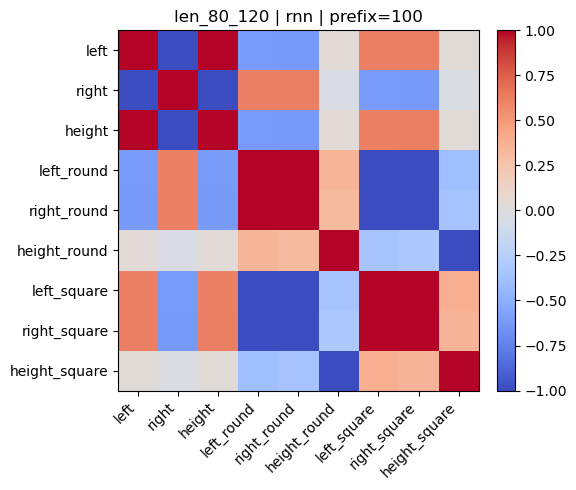

saved figure -> /home/hp_twist_shan/Research/Hidden State Evaluation/results/dyck23_cfg_next_token_50_noise_len_80_120/figures/supervised_projection/len_80_120_rnn_height_projection.png


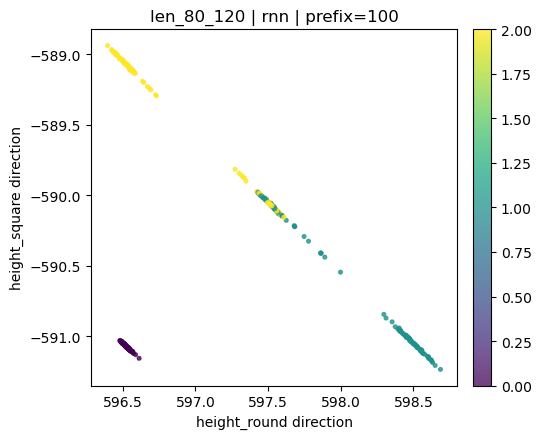

saved figure -> /home/hp_twist_shan/Research/Hidden State Evaluation/results/dyck23_cfg_next_token_50_noise_len_80_120/figures/directions/len_80_120_lstm_direction_heatmap.png


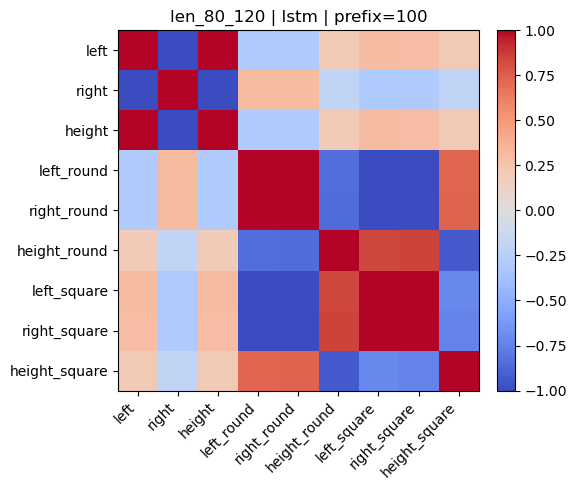

saved figure -> /home/hp_twist_shan/Research/Hidden State Evaluation/results/dyck23_cfg_next_token_50_noise_len_80_120/figures/supervised_projection/len_80_120_lstm_height_projection.png


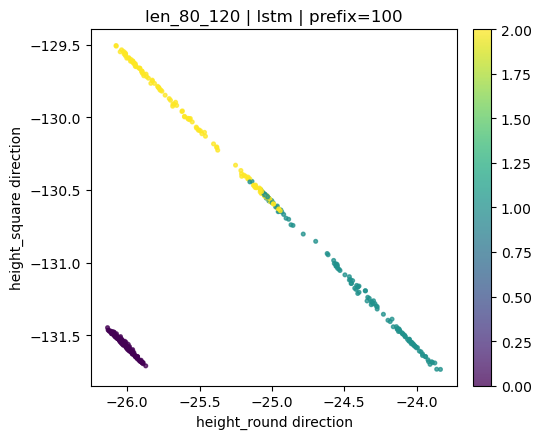

saved figure -> /home/hp_twist_shan/Research/Hidden State Evaluation/results/dyck23_cfg_next_token_50_noise_len_80_120/figures/directions/len_80_120_transformer_direction_heatmap.png


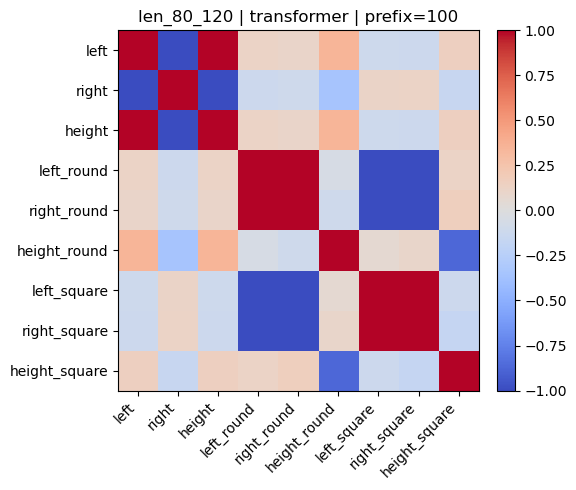

saved figure -> /home/hp_twist_shan/Research/Hidden State Evaluation/results/dyck23_cfg_next_token_50_noise_len_80_120/figures/supervised_projection/len_80_120_transformer_height_projection.png


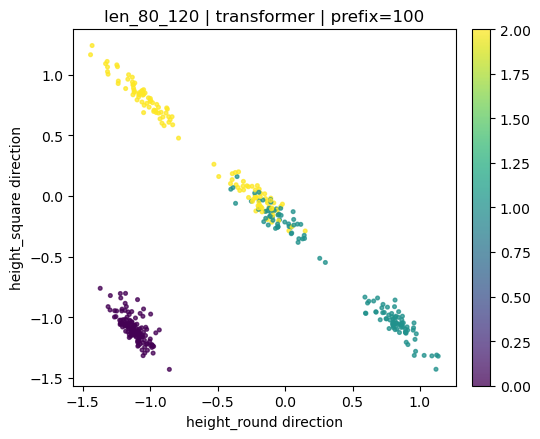

saved figure -> /home/hp_twist_shan/Research/Hidden State Evaluation/results/dyck23_cfg_next_token_50_noise_len_80_120/figures/directions/len_80_120_mamba_direction_heatmap.png


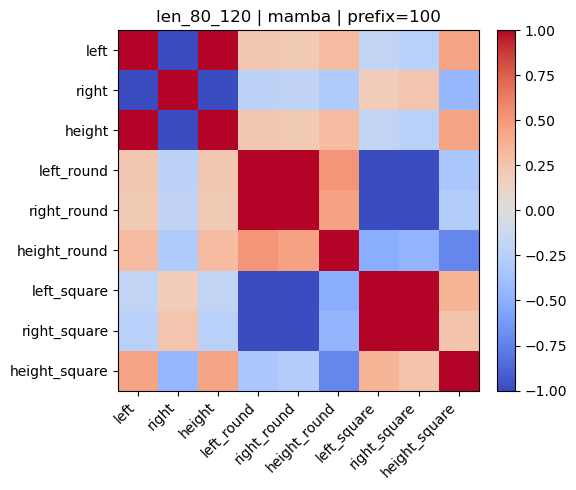

saved figure -> /home/hp_twist_shan/Research/Hidden State Evaluation/results/dyck23_cfg_next_token_50_noise_len_80_120/figures/supervised_projection/len_80_120_mamba_height_projection.png


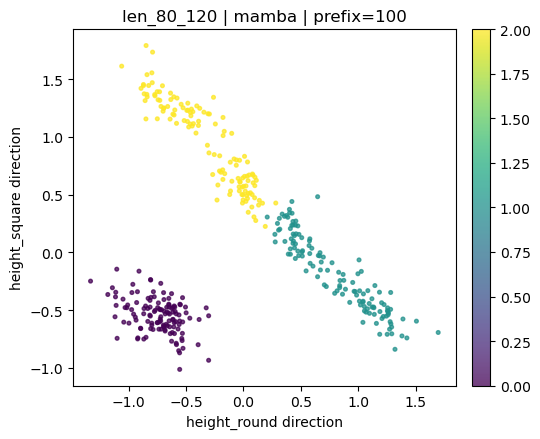

In [7]:
def cosine_matrix(vectors):
    names = list(vectors)
    W = np.stack([vectors[name] for name in names])
    W = W / (np.linalg.norm(W, axis=1, keepdims=True) + 1e-12)
    return names, W @ W.T


def plot_direction_cosine_heatmap(result, title, save_stem):
    fitted = result['fitted']
    vectors = {}
    for key, value in fitted.items():
        if not key.startswith('ridge_'):
            continue
        weight = extract_linear_weight(value['probe'])
        if weight.ndim == 1 and weight.size:
            vectors[key.replace('ridge_', '')] = weight
    if len(vectors) < 2:
        return
    names, C = cosine_matrix(vectors)
    fig, ax = plt.subplots(figsize=(6, 5))
    im = ax.imshow(C, vmin=-1, vmax=1, cmap='coolwarm')
    ax.set_xticks(range(len(names)), names, rotation=45, ha='right')
    ax.set_yticks(range(len(names)), names)
    ax.set_title(title)
    fig.colorbar(im, ax=ax, fraction=0.046, pad=0.04)
    finalize_figure(fig, 'directions', save_stem)
    plt.show()


def plot_supervised_projection(result, title, save_stem, max_points=PCA_MAX_POINTS):
    data = result['data']
    labels = data['labels']
    X = data['X']
    fitted = result['fitted']
    if len(labels) > max_points:
        idx = np.random.default_rng(SEED).choice(len(labels), size=max_points, replace=False)
        X = X[idx]
        labels = labels.iloc[idx].reset_index(drop=True)
    wx = extract_linear_weight(fitted['ridge_height_round']['probe'])
    wy = extract_linear_weight(fitted['ridge_height_square']['probe'])
    Z = np.stack([X @ wx, X @ wy], axis=1)
    fig, ax = plt.subplots(figsize=(5.5, 4.5))
    sc = ax.scatter(Z[:, 0], Z[:, 1], c=labels['top_type_class'], s=7, cmap='viridis', alpha=0.75)
    ax.set_xlabel('height_round direction')
    ax.set_ylabel('height_square direction')
    ax.set_title(title)
    fig.colorbar(sc, ax=ax, fraction=0.046, pad=0.04)
    finalize_figure(fig, 'supervised_projection', save_stem)
    plt.show()


for length_bin in DYCK23_LENGTH_BINS:
    for model_type in MODEL_TYPES:
        result = fixed_probe_results[(length_bin, model_type)]
        title = f'{length_bin} | {model_type} | prefix={result["prefix"]}'
        plot_direction_cosine_heatmap(result, title, f'{length_bin}_{model_type}_direction_heatmap')
        plot_supervised_projection(result, title, f'{length_bin}_{model_type}_height_projection')


Direction heatmap 和 supervised projection 显示：counter 方向不是独立的原始 round/square 坐标，而更像受 Dyck 约束的“总深度 + 类型差异”坐标。`height_round` 和 `height_square` 的投影能形成三角形合法格点，说明 noise 没有把 per-type depth 几何冲掉。

RNN 和 Transformer 的格点/方向通常更干净；LSTM 和 Mamba 的点云更连续一些，说明 counter 可读性有，但几何更松散。


## 5. All-prefix counter lattice views

Fixed-prefix projections are intentionally controlled, but Dyck-(2,3) has a depth parity constraint at a single prefix. These all-prefix views balance by `(height_round, height_square)` and refit just those two counter probes, making the available integer lattice points easier to see.


saved figure -> /home/hp_twist_shan/Research/Hidden State Evaluation/results/dyck23_cfg_next_token_50_noise_len_80_120/figures/counter_lattices/len_80_120_rnn_height_round_vs_height_square_all_prefixes.png


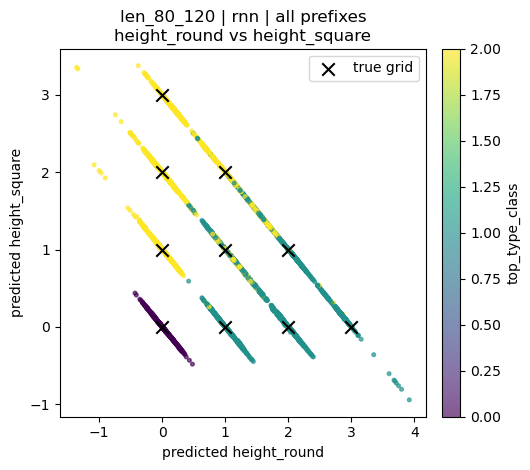

saved figure -> /home/hp_twist_shan/Research/Hidden State Evaluation/results/dyck23_cfg_next_token_50_noise_len_80_120/figures/counter_lattices/len_80_120_lstm_height_round_vs_height_square_all_prefixes.png


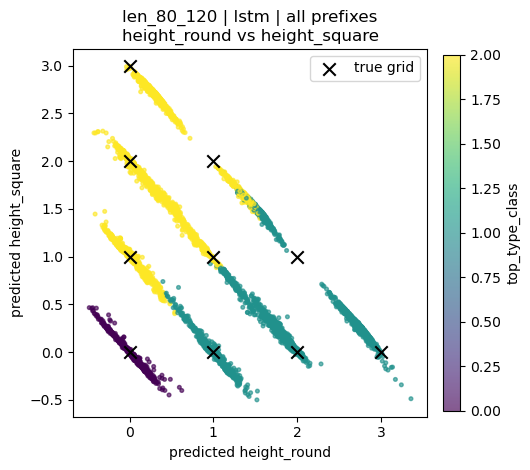

saved figure -> /home/hp_twist_shan/Research/Hidden State Evaluation/results/dyck23_cfg_next_token_50_noise_len_80_120/figures/counter_lattices/len_80_120_transformer_height_round_vs_height_square_all_prefixes.png


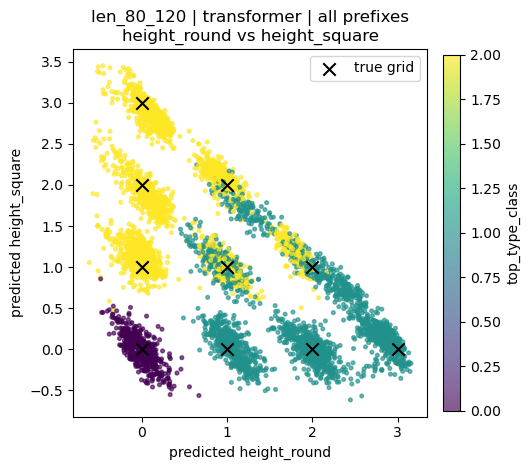

saved figure -> /home/hp_twist_shan/Research/Hidden State Evaluation/results/dyck23_cfg_next_token_50_noise_len_80_120/figures/counter_lattices/len_80_120_mamba_height_round_vs_height_square_all_prefixes.png


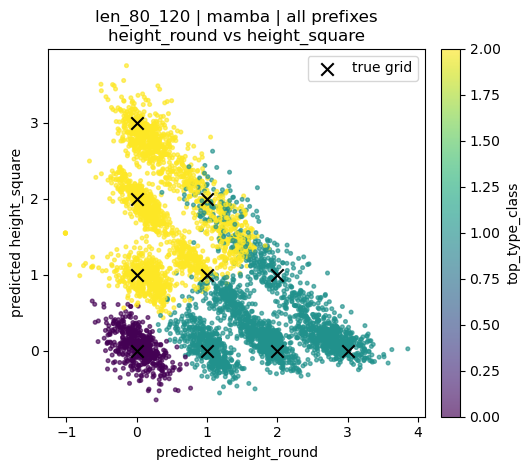

,length_bin,model,prefix,x_target,y_target,x_mae_to_integer,y_mae_to_integer,joint_round_exact,n_grid_points,n
0,len_80_120,rnn,all,height_round,height_square,0.173482,0.172833,0.971680,10,5120
1,len_80_120,lstm,all,height_round,height_square,0.269346,0.268279,0.836523,10,5120
2,len_80_120,transformer,all,height_round,height_square,0.156210,0.174266,0.969727,10,5120
3,len_80_120,mamba,all,height_round,height_square,0.239572,0.210957,0.870117,10,5120


In [8]:
def balance_data_by_counter_pair(data, x_target='height_round', y_target='height_square', seed=0, max_per_pair=512, min_per_pair=8):
    labels = data['labels']
    rng = np.random.default_rng(seed)
    chosen = []
    for _, idx in labels.groupby([x_target, y_target]).indices.items():
        idx = np.asarray(idx)
        if len(idx) < min_per_pair:
            continue
        take = min(len(idx), max_per_pair)
        chosen.append(rng.choice(idx, size=take, replace=False))
    if not chosen:
        return data
    chosen = np.sort(np.concatenate(chosen))
    return {'X': data['X'][chosen], 'labels': labels.iloc[chosen].reset_index(drop=True), 'run_dir': data['run_dir']}


def fit_counter_pair_result(data, x_target='height_round', y_target='height_square', seed=0):
    X = data['X']
    labels = data['labels']
    train_idx, test_idx = _split_indices(len(labels), seed=seed)
    fitted = {}
    for target in [x_target, y_target, 'height']:
        if target not in labels:
            continue
        fitted[f'ridge_{target}'] = fit_ridge_train_test(
            X[train_idx],
            labels[target].to_numpy()[train_idx],
            X[test_idx],
            labels[target].to_numpy()[test_idx],
            target,
        )
    return {'data': data, 'fitted': fitted, 'table': pd.DataFrame(), 'prefix': 'all'}



def _counter_projection(result, target):
    X = result['data']['X']
    probe = result['fitted'][f'ridge_{target}']['probe']
    weight = extract_linear_weight(probe)
    intercept = float(probe.get('intercept', 0.0))
    return X @ weight + intercept


def counter_grid_scores(result, target_pairs=GRID_TARGET_PAIRS):
    labels = result['data']['labels']
    rows = []
    for x_target, y_target in target_pairs:
        if f'ridge_{x_target}' not in result['fitted'] or f'ridge_{y_target}' not in result['fitted']:
            continue
        x_pred = _counter_projection(result, x_target)
        y_pred = _counter_projection(result, y_target)
        x_true = labels[x_target].to_numpy(dtype=float)
        y_true = labels[y_target].to_numpy(dtype=float)
        x_round = np.rint(x_pred)
        y_round = np.rint(y_pred)
        grid_points = labels[[x_target, y_target]].drop_duplicates()
        rows.append({
            'x_target': x_target,
            'y_target': y_target,
            'x_mae_to_integer': float(np.abs(x_pred - x_true).mean()),
            'y_mae_to_integer': float(np.abs(y_pred - y_true).mean()),
            'joint_round_exact': float(((x_round == x_true) & (y_round == y_true)).mean()),
            'n_grid_points': int(len(grid_points)),
            'n': int(len(labels)),
        })
    return rows


def plot_counter_grid_projection(
    result,
    title,
    save_stem,
    x_target='height_round',
    y_target='height_square',
    max_points=7_000,
    section='counter_lattices',
):
    data = result['data']
    labels = data['labels']
    if f'ridge_{x_target}' not in result['fitted'] or f'ridge_{y_target}' not in result['fitted']:
        return
    x_pred = _counter_projection(result, x_target)
    y_pred = _counter_projection(result, y_target)
    idx = np.arange(len(labels))
    if len(idx) > max_points:
        idx = np.random.default_rng(SEED).choice(idx, size=max_points, replace=False)
    color_target = 'top_type_class' if 'top_type_class' in labels else y_target
    fig, ax = plt.subplots(figsize=(5.4, 4.8))
    sc = ax.scatter(
        x_pred[idx],
        y_pred[idx],
        c=labels[color_target].to_numpy()[idx],
        s=7,
        cmap='viridis',
        alpha=0.65,
    )
    grid_points = labels[[x_target, y_target]].drop_duplicates().sort_values([x_target, y_target])
    ax.scatter(
        grid_points[x_target],
        grid_points[y_target],
        marker='x',
        s=80,
        linewidths=1.5,
        color='black',
        label='true grid',
    )
    ax.set_xlabel(f'predicted {x_target}')
    ax.set_ylabel(f'predicted {y_target}')
    ax.set_title(title)
    ax.legend(loc='best')
    fig.colorbar(sc, ax=ax, fraction=0.046, pad=0.04, label=color_target)
    finalize_figure(fig, section, save_stem)
    plt.show()
    plt.close(fig)

lattice_rows = []
for length_bin in DYCK23_LENGTH_BINS:
    for model_type in MODEL_TYPES:
        raw = run_arrays[(length_bin, model_type)]
        data = balance_data_by_counter_pair(raw, seed=SEED)
        result = fit_counter_pair_result(data, seed=SEED)
        base = {'length_bin': length_bin, 'model': model_type, 'prefix': 'all'}
        for row in counter_grid_scores(result, target_pairs=[('height_round', 'height_square')]):
            lattice_rows.append({**base, **row})
        plot_counter_grid_projection(
            result,
            f'{length_bin} | {model_type} | all prefixes\nheight_round vs height_square',
            f'{length_bin}_{model_type}_height_round_vs_height_square_all_prefixes',
            x_target='height_round',
            y_target='height_square',
            max_points=7_000,
            section='counter_lattices',
        )

counter_lattice_df = pd.DataFrame(lattice_rows)
counter_lattice_df.to_csv(RESULTS_ROOT / 'counter_lattice_summary.csv', index=False)
counter_lattice_df


All-prefix counter lattice 给了一个更直接的格点质量指标：RNN 和 Transformer 的 joint rounded exact 都约 0.97，Mamba 约 0.87，LSTM 约 0.84。也就是说，在所有 prefix 混合后，RNN/Transformer 的 `(height_round, height_square)` 几乎落在正确整数格点上，LSTM/Mamba 也有明显 lattice，但更糊。

这进一步支持一个结论：低 overall next-token accuracy 主要是随机 noise 预测拖低；hidden state 对 Dyck counter/stack 信息并不弱。


## 6. Prefix sweep

In [9]:
def run_prefix_sweep_for_run(length_bin, model_type):
    rows = []
    directions = {}
    raw = run_arrays[(length_bin, model_type)]
    for prefix in SWEEP_PREFIX_BY_BIN[length_bin]:
        data = balance_data_by_label(select_prefix(raw, prefix), seed=SEED)
        if len(data['labels']) < 32:
            continue
        fitted, table = run_stack_probes(data, seed=SEED)
        lookup = {(r.probe_type, r.target): r for r in table.itertuples()}
        row = {'length_bin': length_bin, 'model': model_type, 'prefix': prefix, 'n': len(data['labels'])}
        for target in ['height', 'height_round', 'height_square']:
            key = ('ridge', target)
            if key in lookup:
                row[f'{target}_r2'] = lookup[key].r2
        for target in ['top_type_class', 'depth_top_class', 'legal_next_class']:
            key = ('logistic', target)
            if key in lookup:
                row[f'{target}_accuracy'] = lookup[key].accuracy
        rows.append(row)
        direction_row = {}
        for target in RIDGE_TARGETS:
            probe = fitted.get(f'ridge_{target}')
            if probe:
                direction_row[target] = extract_linear_weight(probe['probe'])
        directions[prefix] = direction_row
    return {'rows': pd.DataFrame(rows), 'directions': directions}


prefix_sweep_results = {}
for length_bin in DYCK23_LENGTH_BINS:
    for model_type in MODEL_TYPES:
        print(f'prefix sweep: {length_bin} {model_type}')
        prefix_sweep_results[(length_bin, model_type)] = run_prefix_sweep_for_run(length_bin, model_type)

prefix_sweep_df = pd.concat([v['rows'] for v in prefix_sweep_results.values()], ignore_index=True)
prefix_sweep_df.to_csv(RESULTS_ROOT / 'prefix_sweep_summary.csv', index=False)
prefix_sweep_df


prefix sweep: len_80_120 rnn
prefix sweep: len_80_120 lstm
prefix sweep: len_80_120 transformer
prefix sweep: len_80_120 mamba


,length_bin,model,prefix,n,height_r2,height_round_r2,height_square_r2,top_type_class_accuracy,depth_top_class_accuracy,legal_next_class_accuracy
0,len_80_120,rnn,84,384,0.999978,0.990721,0.992733,1.000000,1.000000,0.843750
1,len_80_120,rnn,88,384,0.999963,0.990652,0.989032,1.000000,1.000000,0.812500
2,len_80_120,rnn,92,384,0.999969,0.986722,0.984812,1.000000,1.000000,0.802083
3,len_80_120,rnn,96,384,0.999979,0.984351,0.986542,1.000000,1.000000,0.781250
4,len_80_120,rnn,100,384,0.999975,0.978768,0.981407,1.000000,1.000000,0.770833
5,len_80_120,rnn,104,384,0.999971,0.987687,0.988361,1.000000,1.000000,0.729167
6,len_80_120,rnn,108,333,0.999957,0.988613,0.989907,1.000000,1.000000,0.686747
7,len_80_120,rnn,112,236,0.999879,0.979932,0.977238,1.000000,1.000000,0.474576
8,len_80_120,rnn,116,144,0.999971,0.911166,0.945230,1.000000,1.000000,0.472222
9,len_80_120,rnn,120,53,1.000000,1.000000,1.000000,NaN,NaN,NaN


Prefix sweep 表明，`height_r2` 几乎全程接近 1，`top_type_class_accuracy` 也几乎全程接近 1；这说明核心 stack state 在长序列后段仍然稳定可读。`height_round/height_square` 的 R2 随模型不同：RNN/Transformer 较高，LSTM/Mamba 中等。

`legal_next_class_accuracy` 越往尾部越下降，尤其 prefix 112/116 附近明显。这更像 CFG 长度预算/终止条件难以线性读出，而不是栈深或栈顶丢失。prefix=120 的行样本少且类别退化，很多 NaN/1.0 不应作为主要结论。


这个 cell 做 prefix sweep：沿每个长度桶的一系列 prefix 位置重复筛样本、平衡类别、拟合 probe，并保存 `prefix_sweep_summary.csv`。它本身主要产出表，不画最终 sweep 图。

表里的每一行是一个模型在某个长度桶、某个 prefix 的 probe 表现。关注 `height_r2`、`top_type_class_accuracy`、`legal_next_class_accuracy` 随 prefix 的变化，可以判断模型是在序列早期还是中后期形成可读出的栈状态。


saved figure -> /home/hp_twist_shan/Research/Hidden State Evaluation/results/dyck23_cfg_next_token_50_noise_len_80_120/figures/sweeps/prefix_sweep.png


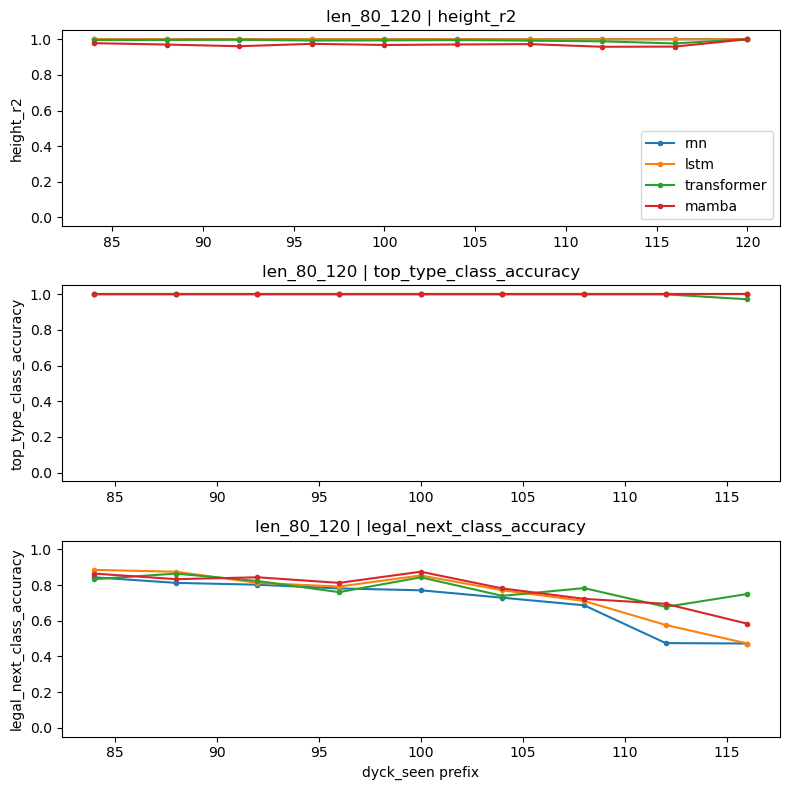

In [10]:
def plot_prefix_sweep(df):
    metrics = ['height_r2', 'top_type_class_accuracy', 'legal_next_class_accuracy']
    fig, axes = plt.subplots(len(metrics), len(DYCK23_LENGTH_BINS), figsize=(8, 8), sharex=False, sharey='row')
    axes = np.asarray(axes).reshape(len(metrics), len(DYCK23_LENGTH_BINS))
    for col, length_bin in enumerate(DYCK23_LENGTH_BINS):
        sub_bin = df.loc[df['length_bin'] == length_bin]
        for row, metric in enumerate(metrics):
            ax = axes[row, col]
            for model_type in MODEL_TYPES:
                sub = sub_bin.loc[sub_bin['model'] == model_type]
                if metric in sub:
                    ax.plot(sub['prefix'], sub[metric], marker='o', ms=3, label=model_type)
            ax.set_title(f'{length_bin} | {metric}')
            ax.set_ylim(-0.05, 1.05)
            if row == len(metrics) - 1:
                ax.set_xlabel('dyck_seen prefix')
            if col == 0:
                ax.set_ylabel(metric)
            if row == 0 and col == len(DYCK23_LENGTH_BINS) - 1:
                ax.legend(loc='lower right')
    finalize_figure(fig, 'sweeps', 'prefix_sweep')
    plt.show()


plot_prefix_sweep(prefix_sweep_df)


这张图把上面的 sweep 结论可视化了：上两行几乎贴着 1，说明 depth/top state 很稳；第三行 `legal_next_class_accuracy` 从 0.8-0.9 区间逐渐走低，到后段有明显掉落。

因此，当前模型比较像“会维护栈状态，但对剩余长度预算/是否该结束的线性表征较弱”。这也解释了为什么 probe 看起来很好，而 next-token exact accuracy 仍然不高。


## 7. Direction arithmetic

In [11]:
def cosine(a, b):
    a = np.asarray(a)
    b = np.asarray(b)
    return float(a @ b / ((np.linalg.norm(a) + 1e-12) * (np.linalg.norm(b) + 1e-12)))


def _counter_pair_column(x_target, y_target):
    return f'cos_{x_target}_{y_target}'


def direction_arithmetic_table(prefix_sweep_results):
    rows = []
    for (length_bin, model_type), result in prefix_sweep_results.items():
        for prefix, directions in result['directions'].items():
            if not {'height', 'height_round', 'height_square'}.issubset(directions):
                continue
            summed = directions['height_round'] + directions['height_square']
            row = {
                'length_bin': length_bin,
                'model': model_type,
                'prefix': prefix,
                'cos_height_round': cosine(directions['height'], directions['height_round']),
                'cos_height_square': cosine(directions['height'], directions['height_square']),
                'cos_round_square': cosine(directions['height_round'], directions['height_square']),
                'cos_height_sum': cosine(directions['height'], summed),
            }
            for x_target, y_target in COUNTER_TARGET_PAIRS:
                if x_target in directions and y_target in directions:
                    pair_col = _counter_pair_column(x_target, y_target)
                    wx = directions[x_target]
                    wy = directions[y_target]
                    w_sum = wx + wy
                    w_diff = wx - wy
                    row[pair_col] = cosine(wx, wy)
                    row[f'{pair_col}_sum_diff'] = cosine(w_sum, w_diff)
                    total_target = COUNTER_TOTAL_TARGETS.get((x_target, y_target))
                    if total_target in directions:
                        wt = directions[total_target]
                        row[f'{pair_col}_total_sum'] = cosine(wt, w_sum)
                        row[f'{pair_col}_total_diff'] = cosine(wt, w_diff)
            rows.append(row)
    return pd.DataFrame(rows)


direction_arithmetic_df = direction_arithmetic_table(prefix_sweep_results)
direction_arithmetic_df.to_csv(RESULTS_ROOT / 'direction_arithmetic_summary.csv', index=False)
direction_arithmetic_df


,length_bin,model,prefix,cos_height_round,cos_height_square,cos_round_square,cos_height_sum,cos_height_round_height_square,cos_height_round_height_square_sum_diff,cos_height_round_height_square_total_sum,cos_height_round_height_square_total_diff,cos_left_round_left_square,cos_left_round_left_square_sum_diff,cos_left_round_left_square_total_sum,cos_left_round_left_square_total_diff,cos_right_round_right_square,cos_right_round_right_square_sum_diff,cos_right_round_right_square_total_sum,cos_right_round_right_square_total_diff
0,len_80_120,rnn,84,-0.486946,0.518115,-0.999350,1.0,-0.999350,-0.502775,1.0,-0.502775,-0.999999,0.628105,1.000000,0.628105,-0.999999,-0.642723,1.000000,-0.642723
1,len_80_120,rnn,88,-0.293198,0.333005,-0.999122,1.0,-0.999122,-0.313308,1.0,-0.313308,-0.999999,-0.110112,1.000000,-0.110112,-0.999998,0.090291,1.000000,0.090291
2,len_80_120,rnn,92,-0.139766,0.190662,-0.998668,1.0,-0.998668,-0.165379,1.0,-0.165379,-0.999996,-0.135001,1.000000,-0.135001,-0.999996,0.115757,1.000000,0.115757
3,len_80_120,rnn,96,-0.262319,0.298916,-0.999273,1.0,-0.999273,-0.280770,1.0,-0.280770,-0.999999,-0.551139,1.000000,-0.551139,-0.999999,0.565491,1.000000,0.565491
4,len_80_120,rnn,100,0.034678,0.028945,-0.997976,1.0,-0.997976,0.002871,1.0,0.002871,-1.000000,-0.611054,1.000000,-0.611054,-1.000000,0.618624,1.000000,0.618624
5,len_80_120,rnn,104,-0.520353,0.562596,-0.998737,1.0,-0.998737,-0.541987,1.0,-0.541987,-1.000000,-0.716001,1.000000,-0.716001,-1.000000,0.712463,1.000000,0.712463
6,len_80_120,rnn,108,-0.350050,0.383909,-0.999338,1.0,-0.999338,-0.367162,1.0,-0.367162,-0.999997,0.137038,1.000000,0.137038,-0.999996,-0.198423,1.000000,-0.198423
7,len_80_120,rnn,112,-0.491266,0.526692,-0.999153,1.0,-0.999153,-0.509303,1.0,-0.509303,-0.999999,-0.523888,1.000000,-0.523888,-0.999999,0.508008,1.000000,0.508008
8,len_80_120,rnn,116,0.008013,0.052527,-0.998167,1.0,-0.998167,-0.022288,1.0,-0.022288,-0.999997,-0.200894,1.000000,-0.200894,-0.999998,0.187253,1.000000,0.187253
9,len_80_120,rnn,120,0.000000,0.000000,0.000000,0.0,0.000000,0.000000,0.0,0.000000,-1.000000,-0.192559,0.683031,0.320403,-1.000000,-0.192559,0.683031,0.320403


Direction arithmetic 的核心结果是：除 prefix=120 这种退化末端外，`cos(height, height_round + height_square)` 基本等于 1。也就是说，hidden state 中总 height 的读出方向几乎就是两类括号 height 方向之和。

同时，raw `height_round` vs `height_square` cosine 多数为负，这不是坏事，而是因为合法状态满足 `height_round + height_square <= 3`，数据本身有强 trade-off。


saved figure -> /home/hp_twist_shan/Research/Hidden State Evaluation/results/dyck23_cfg_next_token_50_noise_len_80_120/figures/sweeps/direction_arithmetic.png


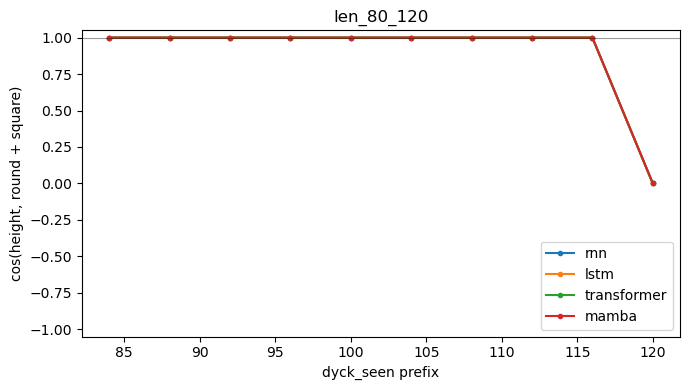

In [12]:
def plot_direction_arithmetic(df):
    fig, axes = plt.subplots(1, len(DYCK23_LENGTH_BINS), figsize=(7, 4), sharey=True)
    axes = np.atleast_1d(axes)
    for ax, length_bin in zip(axes, DYCK23_LENGTH_BINS):
        sub_bin = df.loc[df['length_bin'] == length_bin]
        for model_type in MODEL_TYPES:
            sub = sub_bin.loc[sub_bin['model'] == model_type]
            ax.plot(sub['prefix'], sub['cos_height_sum'], marker='o', ms=3, label=model_type)
        ax.axhline(1.0, color='black', lw=0.8, alpha=0.4)
        ax.set_title(length_bin)
        ax.set_xlabel('dyck_seen prefix')
        ax.set_ylim(-1.05, 1.05)
    axes[0].set_ylabel('cos(height, round + square)')
    axes[-1].legend(loc='lower right')
    finalize_figure(fig, 'sweeps', 'direction_arithmetic')
    plt.show()


plot_direction_arithmetic(direction_arithmetic_df)


图上 `cos(height, round + square)` 基本是一条贴着 1 的线，说明 total depth = round depth + square depth 的线性结构非常稳定。最后 prefix=120 掉到 0 是退化点。

## 8. Counter orthogonality plots

The fixed-prefix table gives one cosine per model/bin/counter pair. The sweep plot shows whether those cosines stay stable as the prefix moves through each length bin.


saved figure -> /home/hp_twist_shan/Research/Hidden State Evaluation/results/dyck23_cfg_next_token_50_noise_len_80_120/figures/counter_orthogonality/fixed_prefix_counter_cosines.png


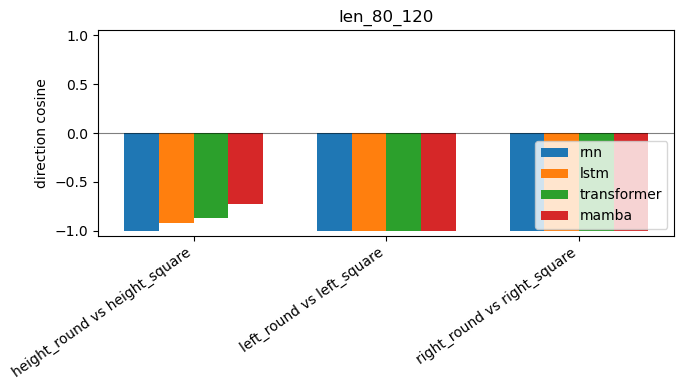

saved figure -> /home/hp_twist_shan/Research/Hidden State Evaluation/results/dyck23_cfg_next_token_50_noise_len_80_120/figures/counter_orthogonality/fixed_prefix_sum_diff_orthogonality.png


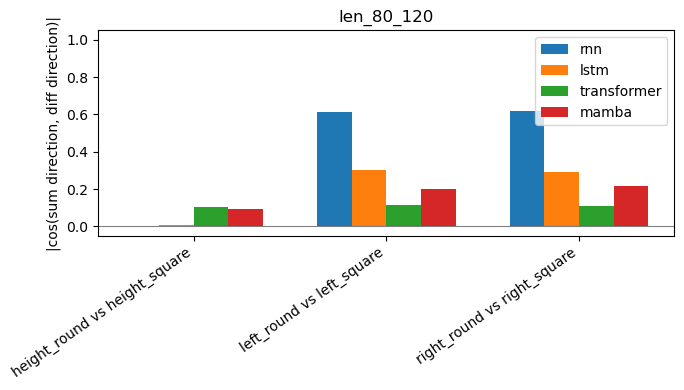

saved figure -> /home/hp_twist_shan/Research/Hidden State Evaluation/results/dyck23_cfg_next_token_50_noise_len_80_120/figures/counter_orthogonality/prefix_sweep_counter_cosines.png


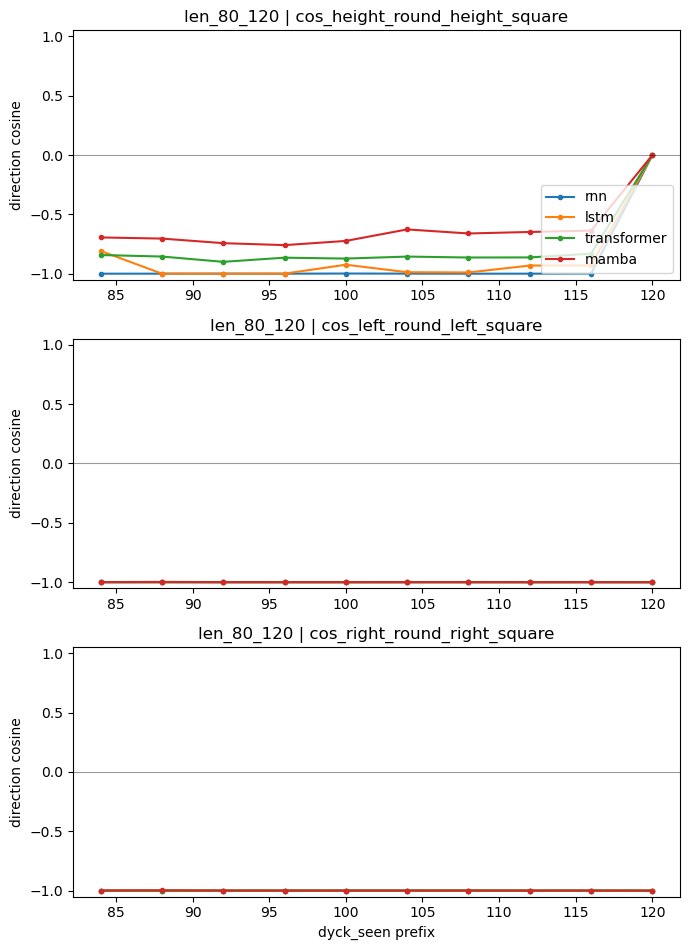

saved figure -> /home/hp_twist_shan/Research/Hidden State Evaluation/results/dyck23_cfg_next_token_50_noise_len_80_120/figures/counter_orthogonality/prefix_sweep_sum_diff_orthogonality.png


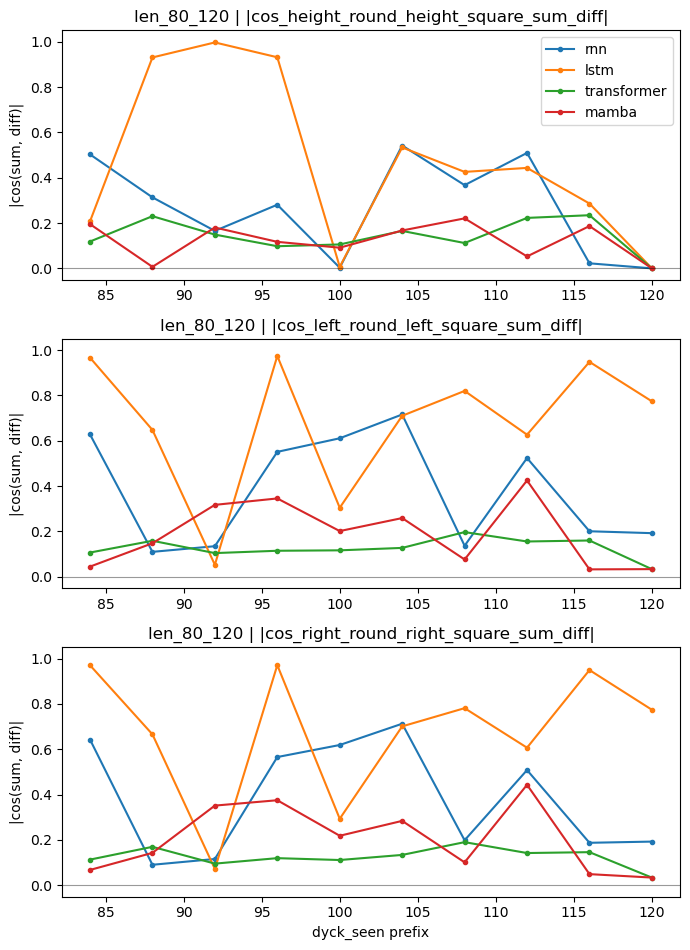

,length_bin,model,prefix,x_target,y_target,cosine,cos_sum_diff,abs_cos_sum_diff,cos_total_sum,cos_total_diff
0,len_80_120,rnn,100,height_round,height_square,-0.997976,0.002871,0.002871,1.0,0.002871
1,len_80_120,rnn,100,left_round,left_square,-1.000000,-0.611054,0.611054,1.0,-0.611054
2,len_80_120,rnn,100,right_round,right_square,-1.000000,0.618624,0.618624,1.0,0.618624
3,len_80_120,lstm,100,height_round,height_square,-0.923695,-0.006878,0.006878,1.0,-0.006878
4,len_80_120,lstm,100,left_round,left_square,-0.999960,-0.304603,0.304603,1.0,-0.304603
5,len_80_120,lstm,100,right_round,right_square,-0.999963,0.293206,0.293206,1.0,0.293206
6,len_80_120,transformer,100,height_round,height_square,-0.871989,0.105550,0.105550,1.0,0.105550
7,len_80_120,transformer,100,left_round,left_square,-0.999925,0.116811,0.116811,1.0,0.116811
8,len_80_120,transformer,100,right_round,right_square,-0.999926,-0.111267,0.111267,1.0,-0.111267
9,len_80_120,mamba,100,height_round,height_square,-0.723332,-0.091259,0.091259,1.0,-0.091259


In [13]:
def plot_fixed_counter_orthogonality(df):
    if df.empty:
        return
    pair_names = [f'{x} vs {y}' for x, y in COUNTER_TARGET_PAIRS]
    fig, axes = plt.subplots(1, len(DYCK23_LENGTH_BINS), figsize=(7, 4), sharey=True)
    axes = np.atleast_1d(axes)
    for ax, length_bin in zip(axes, DYCK23_LENGTH_BINS):
        sub = df.loc[df['length_bin'] == length_bin].copy()
        sub['pair'] = sub['x_target'] + ' vs ' + sub['y_target']
        x = np.arange(len(pair_names))
        width = 0.18
        for offset, model_type in enumerate(MODEL_TYPES):
            vals = []
            for pair in pair_names:
                part = sub.loc[(sub['model'] == model_type) & (sub['pair'] == pair), 'cosine']
                vals.append(float(part.iloc[0]) if len(part) else np.nan)
            ax.bar(x + (offset - 1.5) * width, vals, width=width, label=model_type)
        ax.axhline(0.0, color='black', lw=0.8, alpha=0.5)
        ax.set_xticks(x, pair_names, rotation=35, ha='right')
        ax.set_title(length_bin)
        ax.set_ylim(-1.05, 1.05)
    axes[0].set_ylabel('direction cosine')
    axes[-1].legend(loc='lower right')
    finalize_figure(fig, 'counter_orthogonality', 'fixed_prefix_counter_cosines')
    plt.show()
    plt.close(fig)


def plot_counter_orthogonality_sweep(df):
    columns = [_counter_pair_column(x, y) for x, y in COUNTER_TARGET_PAIRS]
    columns = [col for col in columns if col in df]
    if not columns:
        return
    fig, axes = plt.subplots(len(columns), len(DYCK23_LENGTH_BINS), figsize=(7, 3.2 * len(columns)), sharey=True)
    axes = np.asarray(axes).reshape(len(columns), len(DYCK23_LENGTH_BINS))
    for row, col_name in enumerate(columns):
        for ax, length_bin in zip(axes[row], DYCK23_LENGTH_BINS):
            sub_bin = df.loc[df['length_bin'] == length_bin]
            for model_type in MODEL_TYPES:
                sub = sub_bin.loc[sub_bin['model'] == model_type]
                ax.plot(sub['prefix'], sub[col_name], marker='o', ms=3, label=model_type)
            ax.axhline(0.0, color='black', lw=0.8, alpha=0.4)
            ax.set_title(f'{length_bin} | {col_name}')
            ax.set_ylim(-1.05, 1.05)
            if row == len(columns) - 1:
                ax.set_xlabel('dyck_seen prefix')
            if ax is axes[row][0]:
                ax.set_ylabel('direction cosine')
    axes[0][-1].legend(loc='lower right')
    finalize_figure(fig, 'counter_orthogonality', 'prefix_sweep_counter_cosines')
    plt.show()
    plt.close(fig)


def plot_fixed_counter_basis_orthogonality(df):
    if df.empty or 'abs_cos_sum_diff' not in df:
        return
    pair_names = [f'{x} vs {y}' for x, y in COUNTER_TARGET_PAIRS]
    fig, axes = plt.subplots(1, len(DYCK23_LENGTH_BINS), figsize=(7, 4), sharey=True)
    axes = np.atleast_1d(axes)
    for ax, length_bin in zip(axes, DYCK23_LENGTH_BINS):
        sub = df.loc[df['length_bin'] == length_bin].copy()
        sub['pair'] = sub['x_target'] + ' vs ' + sub['y_target']
        x = np.arange(len(pair_names))
        width = 0.18
        for offset, model_type in enumerate(MODEL_TYPES):
            vals = []
            for pair in pair_names:
                part = sub.loc[(sub['model'] == model_type) & (sub['pair'] == pair), 'abs_cos_sum_diff']
                vals.append(float(part.iloc[0]) if len(part) else np.nan)
            ax.bar(x + (offset - 1.5) * width, vals, width=width, label=model_type)
        ax.axhline(0.0, color='black', lw=0.8, alpha=0.5)
        ax.set_xticks(x, pair_names, rotation=35, ha='right')
        ax.set_title(length_bin)
        ax.set_ylim(-0.05, 1.05)
    axes[0].set_ylabel('|cos(sum direction, diff direction)|')
    axes[-1].legend(loc='upper right')
    finalize_figure(fig, 'counter_orthogonality', 'fixed_prefix_sum_diff_orthogonality')
    plt.show()
    plt.close(fig)


def plot_counter_basis_sweep(df):
    columns = [f'{_counter_pair_column(x, y)}_sum_diff' for x, y in COUNTER_TARGET_PAIRS]
    columns = [col for col in columns if col in df]
    if not columns:
        return
    fig, axes = plt.subplots(len(columns), len(DYCK23_LENGTH_BINS), figsize=(7, 3.2 * len(columns)), sharey=True)
    axes = np.asarray(axes).reshape(len(columns), len(DYCK23_LENGTH_BINS))
    for row, col_name in enumerate(columns):
        for ax, length_bin in zip(axes[row], DYCK23_LENGTH_BINS):
            sub_bin = df.loc[df['length_bin'] == length_bin]
            for model_type in MODEL_TYPES:
                sub = sub_bin.loc[sub_bin['model'] == model_type]
                ax.plot(sub['prefix'], sub[col_name].abs(), marker='o', ms=3, label=model_type)
            ax.axhline(0.0, color='black', lw=0.8, alpha=0.4)
            ax.set_title(f'{length_bin} | |{col_name}|')
            ax.set_ylim(-0.05, 1.05)
            if row == len(columns) - 1:
                ax.set_xlabel('dyck_seen prefix')
            if ax is axes[row][0]:
                ax.set_ylabel('|cos(sum, diff)|')
    axes[0][-1].legend(loc='upper right')
    finalize_figure(fig, 'counter_orthogonality', 'prefix_sweep_sum_diff_orthogonality')
    plt.show()
    plt.close(fig)


def fixed_counter_orthogonality_table(fixed_probe_results):
    rows = []
    for (length_bin, model_type), result in fixed_probe_results.items():
        directions = {}
        for target in RIDGE_TARGETS:
            probe = result['fitted'].get(f'ridge_{target}')
            if probe and probe.get('probe') is not None:
                weight = extract_linear_weight(probe['probe'])
                if weight.ndim == 1 and weight.size:
                    directions[target] = weight
        for x_target, y_target in COUNTER_TARGET_PAIRS:
            if x_target not in directions or y_target not in directions:
                continue
            wx = directions[x_target]
            wy = directions[y_target]
            w_sum = wx + wy
            w_diff = wx - wy
            row = {
                'length_bin': length_bin,
                'model': model_type,
                'prefix': result['prefix'],
                'x_target': x_target,
                'y_target': y_target,
                'cosine': cosine(wx, wy),
                'cos_sum_diff': cosine(w_sum, w_diff),
                'abs_cos_sum_diff': abs(cosine(w_sum, w_diff)),
            }
            total_target = COUNTER_TOTAL_TARGETS.get((x_target, y_target))
            if total_target in directions:
                wt = directions[total_target]
                row['cos_total_sum'] = cosine(wt, w_sum)
                row['cos_total_diff'] = cosine(wt, w_diff)
            rows.append(row)
    return pd.DataFrame(rows)


fixed_counter_orthogonality_df = fixed_counter_orthogonality_table(fixed_probe_results)
fixed_counter_orthogonality_df.to_csv(RESULTS_ROOT / 'fixed_counter_orthogonality_summary.csv', index=False)
fixed_counter_grid_df = fixed_counter_orthogonality_df.copy()


plot_fixed_counter_orthogonality(fixed_counter_orthogonality_df)
plot_fixed_counter_basis_orthogonality(fixed_counter_orthogonality_df)
plot_counter_orthogonality_sweep(direction_arithmetic_df)
plot_counter_basis_sweep(direction_arithmetic_df)
fixed_counter_grid_df


Counter orthogonality 汇总显示：raw `round` 和 `square` counter direction 普遍不是正交，而是强负相关；固定 prefix 上尤其明显，因为 round 多了 square 往往就少。`height_round` vs `height_square` 的 cosine：RNN -0.998、LSTM -0.924、Transformer -0.872、Mamba -0.723。

更有意思的是 sum/diff basis：`height_round + height_square` 对齐 total height，而 sum/diff 的正交性在 height counter 上很好；left/right cumulative counter 则 RNN 纠缠更强，Transformer/Mamba 更接近一个干净的总量轴 + 类型差异轴。总体结论是：模型没有把两类 counter 编成两个独立正交原始轴，而是在 Dyck 合法状态约束下学了更压缩的坐标系。


## 9. Transformer attention outlier-token check under 50% noise

This section analyzes only the trained Transformer run, because RNN/LSTM/Mamba do not expose attention maps. The question is whether planted random noise creates outlier tokens or attention sinks.

The analysis compares each source token's received attention against a causal-uniform baseline. `sink_ratio = observed / baseline` captures relative enrichment, while `excess_mass = observed - baseline` is the safer absolute sink score. For the noise setting, summaries are reported both by individual token and by token group: `BOS`, `noise`, `open`, and `close`.

In [14]:
from collections import Counter
from hse.models import build_model
from hse.tasks.dyck23 import build_prefix_labels

ATTENTION_MODEL = 'transformer'
ATTENTION_LENGTH_BIN = 'len_80_120'
ATTENTION_EXAMPLES = 64
ATTENTION_BATCH_SIZE = 8
ATTENTION_SEED = SEED + 50_025
RUN_ATTENTION_ANALYSIS = False  # Set True to recompute attention maps from the checkpoint.
ATTENTION_ALLOW_OVERWRITE = False

ATTENTION_RUN_DIR = RESULTS_ROOT / ATTENTION_LENGTH_BIN / f'{ATTENTION_MODEL}_seed{SEED}'
ATTENTION_ROOT = RESULTS_ROOT / 'attention' / f'{ATTENTION_MODEL}_seed{ATTENTION_SEED}_n{ATTENTION_EXAMPLES}'
ATTENTION_FIGURES_ROOT = ATTENTION_ROOT / 'figures'


def load_attention_transformer(run_dir, device=DEVICE):
    run_dir = Path(run_dir)
    config = json.load(open(run_dir / 'config.json'))
    task_config = Dyck23Config(**config['task'])
    model_spec = dict(config['model'])
    model_kwargs = {k: v for k, v in model_spec.items() if k != 'state_kind'}
    model = build_model(model_name='transformer', vocab_size=task_config.vocab_size, **model_kwargs)
    ckpt_path = run_dir / 'checkpoints' / 'model_best.pt'
    if not ckpt_path.exists():
        ckpt_path = run_dir / 'checkpoints' / 'model_final.pt'
    ckpt = torch.load(ckpt_path, map_location='cpu')
    model.load_state_dict(ckpt['model'])
    model.to(device).eval()
    return model, task_config


def transformer_forward_with_attention(model, x):
    batch_size, seq_len = x.shape
    pos = torch.arange(seq_len, device=x.device).unsqueeze(0).expand(batch_size, -1)
    h = model.embed(x)
    if model.embed_scale:
        h = h * np.sqrt(model.emb_dim)
    if model.pos_encoding_type == 'sinusoidal':
        h = h + model.sinusoidal_pos[:seq_len].to(device=x.device).unsqueeze(0)
    else:
        h = h + model.pos_embed(pos)

    causal_mask = torch.triu(torch.ones(seq_len, seq_len, device=x.device, dtype=torch.bool), diagonal=1)
    attns = []
    for layer in model.layers:
        if getattr(layer, 'norm_first', False):
            y = layer.norm1(h)
            attn_out, attn = layer.self_attn(
                y, y, y,
                attn_mask=causal_mask,
                need_weights=True,
                average_attn_weights=False,
            )
            h = h + layer.dropout1(attn_out)
            y = layer.norm2(h)
            y = layer.linear2(layer.dropout(layer.activation(layer.linear1(y))))
            h = h + layer.dropout2(y)
        else:
            attn_out, attn = layer.self_attn(
                h, h, h,
                attn_mask=causal_mask,
                need_weights=True,
                average_attn_weights=False,
            )
            h = layer.norm1(h + layer.dropout1(attn_out))
            y = layer.linear2(layer.dropout(layer.activation(layer.linear1(h))))
            h = layer.norm2(h + layer.dropout2(y))
        attns.append(attn.detach())

    h = model.final_norm(h)
    logits = model.output(h)
    return logits, torch.stack(attns, dim=0)


def attention_token_name(token, config):
    token = int(token)
    if token == config.pad_token:
        return 'PAD'
    if token == config.bos_token:
        return 'BOS'
    if token == config.eos_token:
        return 'EOS'
    if token in config.noise_tokens:
        return f'noise_{token - min(config.noise_tokens):02d}'
    mapping = {}
    for name, open_tok, close_tok in zip(config.type_names, config.open_tokens, config.close_tokens):
        mapping[int(open_tok)] = f'open_{name}'
        mapping[int(close_tok)] = f'close_{name}'
    return mapping.get(token, f'token_{token}')


def attention_token_group(token, config):
    token = int(token)
    if token == config.bos_token:
        return 'BOS'
    if token == config.eos_token:
        return 'EOS'
    if token == config.pad_token:
        return 'PAD'
    if token in config.noise_tokens:
        return 'noise'
    if token in config.open_tokens:
        return 'open'
    if token in config.close_tokens:
        return 'close'
    return 'other'


def attention_outlier_frames(model, batch, config, *, chunk_size=8, device=DEVICE):
    source_rows = []
    query_rows = []
    head_rows = []
    labels = build_prefix_labels(batch, config)
    labels_by_key = {(int(r.example_id), int(r.position)): r for r in labels.itertuples(index=False)}
    tokens_cpu = batch.tokens.detach().cpu()
    lengths_cpu = batch.lengths.detach().cpu().numpy()
    target_mask_cpu = batch.target_mask.detach().cpu().numpy()
    group_cache = {tok: attention_token_group(tok, config) for tok in range(config.vocab_size)}
    name_cache = {tok: attention_token_name(tok, config) for tok in range(config.vocab_size)}

    for start in range(0, int(tokens_cpu.shape[0]), chunk_size):
        stop = min(start + chunk_size, int(tokens_cpu.shape[0]))
        tokens = tokens_cpu[start:stop].to(device)
        with torch.no_grad():
            _, attns = transformer_forward_with_attention(model, tokens)
        attns = attns.detach().cpu()
        n_layers, local_bsz, n_heads, _, _ = attns.shape

        for local_idx in range(local_bsz):
            example_id = start + local_idx
            L = int(lengths_cpu[example_id])
            query_positions = np.where(target_mask_cpu[example_id, :L])[0] - 1
            query_positions = query_positions[(query_positions >= 0) & (query_positions < L)]
            if len(query_positions) == 0:
                continue

            A = attns[:, local_idx, :, :L, :L]
            mean_A = A.mean(dim=(0, 1)).numpy()
            received = mean_A[query_positions, :L].sum(axis=0) / len(query_positions)
            baseline = np.zeros(L, dtype=float)
            for q in query_positions:
                baseline[:q + 1] += 1.0 / (q + 1)
            baseline /= len(query_positions)
            seq_tokens = tokens_cpu[example_id, :L].numpy()
            seq_groups = np.array([group_cache[int(tok)] for tok in seq_tokens])

            for pos in range(L):
                base = float(baseline[pos])
                obs = float(received[pos])
                if base <= 0:
                    continue
                tok = int(seq_tokens[pos])
                source_rows.append({
                    'example_id': example_id,
                    'source_position': pos,
                    'relative_position': pos / max(L - 1, 1),
                    'token': tok,
                    'token_name': name_cache[tok],
                    'token_group': group_cache[tok],
                    'observed_mass': obs,
                    'uniform_baseline_mass': base,
                    'excess_mass': obs - base,
                    'sink_ratio': obs / base,
                    'is_bos': pos == 0,
                    'is_first_payload': pos == 1,
                })

            for q in query_positions:
                label_row = labels_by_key.get((example_id, int(q)))
                if label_row is None:
                    continue
                scores = mean_A[q, :q + 1]
                top_src = int(np.argmax(scores))
                q_tok = int(seq_tokens[q])
                source_groups_visible = seq_groups[:q + 1]
                query_rows.append({
                    'example_id': example_id,
                    'position': int(q),
                    'relative_position': q / max(L - 1, 1),
                    'query_token': q_tok,
                    'query_token_name': name_cache[q_tok],
                    'query_token_group': group_cache[q_tok],
                    'query_is_dyck_position': bool(label_row.is_dyck_position),
                    'height': int(label_row.height),
                    'top_type_class': int(label_row.top_type_class),
                    'legal_next_class': int(label_row.legal_next_class),
                    'dyck_seen': int(label_row.dyck_seen),
                    'bos_mass': float(scores[0]),
                    'noise_source_mass': float(scores[source_groups_visible == 'noise'].sum()),
                    'bracket_source_mass': float(scores[np.isin(source_groups_visible, ['open', 'close'])].sum()),
                    'self_mass': float(scores[q]),
                    'prev_mass': float(scores[q - 1]) if q > 0 else np.nan,
                    'max_source_position': top_src,
                    'max_source_token': int(seq_tokens[top_src]),
                    'max_source_token_name': name_cache[int(seq_tokens[top_src])],
                    'max_source_token_group': group_cache[int(seq_tokens[top_src])],
                    'max_attention_mass': float(scores[top_src]),
                    'max_source_is_bos': top_src == 0,
                })

            for layer in range(n_layers):
                for head in range(n_heads):
                    H = A[layer, head].numpy()
                    received_h = H[query_positions, :L].sum(axis=0) / len(query_positions)
                    ratio = np.divide(received_h, baseline, out=np.zeros_like(received_h), where=baseline > 0)
                    excess = received_h - baseline
                    top_ratio_src = int(np.argmax(ratio))
                    top_excess_src = int(np.argmax(excess))
                    ratio_tok = int(seq_tokens[top_ratio_src])
                    excess_tok = int(seq_tokens[top_excess_src])
                    head_rows.append({
                        'example_id': example_id,
                        'layer': layer,
                        'head': head,
                        'max_sink_ratio': float(ratio[top_ratio_src]),
                        'ratio_top_excess_mass': float(excess[top_ratio_src]),
                        'ratio_top_source_position': top_ratio_src,
                        'ratio_top_source_token': ratio_tok,
                        'ratio_top_source_token_name': name_cache[ratio_tok],
                        'ratio_top_source_token_group': group_cache[ratio_tok],
                        'ratio_top_source_is_bos': top_ratio_src == 0,
                        'ratio_top_source_is_noise': group_cache[ratio_tok] == 'noise',
                        'max_excess_mass': float(excess[top_excess_src]),
                        'excess_top_sink_ratio': float(ratio[top_excess_src]),
                        'excess_top_source_position': top_excess_src,
                        'excess_top_source_token': excess_tok,
                        'excess_top_source_token_name': name_cache[excess_tok],
                        'excess_top_source_token_group': group_cache[excess_tok],
                        'excess_top_source_is_bos': top_excess_src == 0,
                        'excess_top_source_is_noise': group_cache[excess_tok] == 'noise',
                    })

    return pd.DataFrame(source_rows), pd.DataFrame(query_rows), pd.DataFrame(head_rows)


def summarize_noise_attention_outliers(source_df, query_df, head_df):
    token_summary = source_df.groupby(['token_group', 'token_name']).agg(
        n=('sink_ratio', 'size'),
        observed=('observed_mass', 'mean'),
        baseline=('uniform_baseline_mass', 'mean'),
        excess=('excess_mass', 'mean'),
        sink_ratio=('sink_ratio', 'mean'),
    ).reset_index()
    group_summary = source_df.groupby('token_group').agg(
        n=('sink_ratio', 'size'),
        observed=('observed_mass', 'mean'),
        baseline=('uniform_baseline_mass', 'mean'),
        excess=('excess_mass', 'mean'),
        sink_ratio=('sink_ratio', 'mean'),
    ).reset_index()
    position_summary = source_df.groupby('source_position').agg(
        n=('sink_ratio', 'size'),
        token_group=('token_group', lambda x: x.mode().iat[0]),
        token_name=('token_name', lambda x: x.mode().iat[0]),
        observed=('observed_mass', 'mean'),
        baseline=('uniform_baseline_mass', 'mean'),
        excess=('excess_mass', 'mean'),
        sink_ratio=('sink_ratio', 'mean'),
    ).reset_index()
    head_summary = head_df.groupby(['layer', 'head']).agg(
        max_sink_ratio_mean=('max_sink_ratio', 'mean'),
        max_excess_mean=('max_excess_mass', 'mean'),
        ratio_noise_top_frac=('ratio_top_source_is_noise', 'mean'),
        excess_noise_top_frac=('excess_top_source_is_noise', 'mean'),
        ratio_bos_top_frac=('ratio_top_source_is_bos', 'mean'),
        excess_bos_top_frac=('excess_top_source_is_bos', 'mean'),
        ratio_top_group=('ratio_top_source_token_group', lambda x: Counter(x).most_common(1)[0][0]),
        excess_top_group=('excess_top_source_token_group', lambda x: Counter(x).most_common(1)[0][0]),
        ratio_top_token=('ratio_top_source_token_name', lambda x: Counter(x).most_common(1)[0][0]),
        excess_top_token=('excess_top_source_token_name', lambda x: Counter(x).most_common(1)[0][0]),
    ).reset_index()
    query_group_summary = query_df.groupby('query_token_group').agg(
        n=('bos_mass', 'size'),
        bos_mass=('bos_mass', 'mean'),
        noise_source_mass=('noise_source_mass', 'mean'),
        bracket_source_mass=('bracket_source_mass', 'mean'),
        self_mass=('self_mass', 'mean'),
        max_mass=('max_attention_mass', 'mean'),
        bos_is_max=('max_source_is_bos', 'mean'),
    ).reset_index()
    query_height_summary = query_df.groupby('height').agg(
        n=('bos_mass', 'size'),
        bos_mass=('bos_mass', 'mean'),
        noise_source_mass=('noise_source_mass', 'mean'),
        bracket_source_mass=('bracket_source_mass', 'mean'),
        self_mass=('self_mass', 'mean'),
        max_mass=('max_attention_mass', 'mean'),
        bos_is_max=('max_source_is_bos', 'mean'),
    ).reset_index()
    query_position_bin_summary = query_df.assign(
        pos_bin=pd.qcut(query_df['relative_position'], 4, duplicates='drop')
    ).groupby('pos_bin', observed=True).agg(
        n=('bos_mass', 'size'),
        bos_mass=('bos_mass', 'mean'),
        noise_source_mass=('noise_source_mass', 'mean'),
        bracket_source_mass=('bracket_source_mass', 'mean'),
        self_mass=('self_mass', 'mean'),
        max_mass=('max_attention_mass', 'mean'),
        bos_is_max=('max_source_is_bos', 'mean'),
    ).reset_index()
    query_position_bin_summary['pos_bin'] = query_position_bin_summary['pos_bin'].astype(str)
    return token_summary, group_summary, position_summary, head_summary, query_group_summary, query_height_summary, query_position_bin_summary


def save_noise_attention_figures(token_summary, group_summary, position_summary, head_summary, figures_root):
    figures_root.mkdir(parents=True, exist_ok=True)
    pos_plot = position_summary.sort_values('source_position')

    fig, ax = plt.subplots(figsize=(8, 4))
    ax.plot(pos_plot['source_position'], pos_plot['observed'], label='observed received mass', linewidth=2)
    ax.plot(pos_plot['source_position'], pos_plot['baseline'], label='causal-uniform baseline', linewidth=2)
    ax.set_xlabel('source position')
    ax.set_ylabel('mean attention mass per query')
    ax.set_title('50-noise Transformer source attention profile')
    ax.legend()
    fig.tight_layout()
    fig.savefig(figures_root / 'source_attention_profile.png', dpi=180)
    plt.show()
    plt.close(fig)

    fig, ax = plt.subplots(figsize=(8, 4))
    ax.plot(pos_plot['source_position'], pos_plot['excess'], color='tab:red')
    ax.axhline(0.0, color='black', linewidth=1)
    ax.set_xlabel('source position')
    ax.set_ylabel('observed - causal-uniform baseline')
    ax.set_title('50-noise attention excess by source position')
    fig.tight_layout()
    fig.savefig(figures_root / 'source_attention_excess.png', dpi=180)
    plt.show()
    plt.close(fig)

    fig, ax = plt.subplots(figsize=(7, 4))
    group_summary.sort_values('excess', ascending=False).plot.bar(x='token_group', y='excess', ax=ax, color='tab:purple', legend=False)
    ax.axhline(0.0, color='black', linewidth=1)
    ax.set_ylabel('mean excess attention')
    ax.set_title('Token-group attention excess')
    fig.tight_layout()
    fig.savefig(figures_root / 'token_group_attention_excess.png', dpi=180)
    plt.show()
    plt.close(fig)

    fig, ax = plt.subplots(figsize=(10, 4))
    token_summary.sort_values('excess', ascending=False).plot.bar(x='token_name', y='excess', ax=ax, color='tab:blue', legend=False)
    ax.axhline(0.0, color='black', linewidth=1)
    ax.set_ylabel('mean excess attention')
    ax.set_title('Token-level attention excess')
    fig.tight_layout()
    fig.savefig(figures_root / 'token_attention_excess.png', dpi=180)
    plt.show()
    plt.close(fig)

    heat = head_summary.pivot(index='layer', columns='head', values='max_excess_mean').sort_index()
    fig, ax = plt.subplots(figsize=(8, 4))
    im = ax.imshow(heat.to_numpy(), aspect='auto', cmap='magma')
    ax.set_xlabel('head')
    ax.set_ylabel('layer')
    ax.set_xticks(range(heat.shape[1]))
    ax.set_xticklabels(heat.columns)
    ax.set_yticks(range(heat.shape[0]))
    ax.set_yticklabels(heat.index)
    ax.set_title('Head-level max attention excess')
    fig.colorbar(im, ax=ax, label='mean max excess')
    fig.tight_layout()
    fig.savefig(figures_root / 'head_max_attention_excess.png', dpi=180)
    plt.show()
    plt.close(fig)

In [15]:
attention_required_paths = [
    ATTENTION_ROOT / 'token_source_summary.csv',
    ATTENTION_ROOT / 'token_group_source_summary.csv',
    ATTENTION_ROOT / 'position_source_summary.csv',
    ATTENTION_ROOT / 'head_outlier_summary.csv',
    ATTENTION_ROOT / 'query_token_group_summary.csv',
    ATTENTION_ROOT / 'query_height_summary.csv',
    ATTENTION_ROOT / 'query_position_bin_summary.csv',
]

if RUN_ATTENTION_ANALYSIS:
    existing_attention_paths = [path for path in attention_required_paths if path.exists()]
    if existing_attention_paths and not ATTENTION_ALLOW_OVERWRITE:
        raise FileExistsError(
            'Refusing to overwrite existing attention analysis artifacts. '
            'Use a new ATTENTION_SEED/ATTENTION_EXAMPLES or set ATTENTION_ALLOW_OVERWRITE=True intentionally. '
            f'First existing path: {existing_attention_paths[0]}'
        )

    attention_model, attention_config = load_attention_transformer(ATTENTION_RUN_DIR, device=DEVICE)
    attention_sampler = Dyck23Sampler(
        Dyck23Config(**{**json.load(open(ATTENTION_RUN_DIR / 'config.json'))['task'], 'device': 'cpu'}),
        seed=ATTENTION_SEED,
    )
    attention_batch = attention_sampler.sample(ATTENTION_EXAMPLES)
    attention_source_df, attention_query_df, attention_head_df = attention_outlier_frames(
        attention_model,
        attention_batch,
        attention_config,
        chunk_size=ATTENTION_BATCH_SIZE,
        device=DEVICE,
    )
    (
        attention_token_summary_df,
        attention_group_summary_df,
        attention_position_summary_df,
        attention_head_summary_df,
        attention_query_group_summary_df,
        attention_query_height_summary_df,
        attention_query_position_bin_summary_df,
    ) = summarize_noise_attention_outliers(attention_source_df, attention_query_df, attention_head_df)

    ATTENTION_ROOT.mkdir(parents=True, exist_ok=True)
    attention_source_df.to_csv(ATTENTION_ROOT / 'source_attention_rows.csv', index=False)
    attention_query_df.to_csv(ATTENTION_ROOT / 'query_attention_rows.csv', index=False)
    attention_head_df.to_csv(ATTENTION_ROOT / 'head_outlier_rows.csv', index=False)
    attention_token_summary_df.to_csv(ATTENTION_ROOT / 'token_source_summary.csv', index=False)
    attention_group_summary_df.to_csv(ATTENTION_ROOT / 'token_group_source_summary.csv', index=False)
    attention_position_summary_df.to_csv(ATTENTION_ROOT / 'position_source_summary.csv', index=False)
    attention_head_summary_df.to_csv(ATTENTION_ROOT / 'head_outlier_summary.csv', index=False)
    attention_query_group_summary_df.to_csv(ATTENTION_ROOT / 'query_token_group_summary.csv', index=False)
    attention_query_height_summary_df.to_csv(ATTENTION_ROOT / 'query_height_summary.csv', index=False)
    attention_query_position_bin_summary_df.to_csv(ATTENTION_ROOT / 'query_position_bin_summary.csv', index=False)
    save_noise_attention_figures(
        attention_token_summary_df,
        attention_group_summary_df,
        attention_position_summary_df,
        attention_head_summary_df,
        ATTENTION_FIGURES_ROOT,
    )
else:
    missing_attention_paths = [path for path in attention_required_paths if not path.exists()]
    if missing_attention_paths:
        raise FileNotFoundError(
            f'Missing attention analysis artifacts under {ATTENTION_ROOT}. '
            'Set RUN_ATTENTION_ANALYSIS=True to compute them.'
        )
    attention_token_summary_df = pd.read_csv(ATTENTION_ROOT / 'token_source_summary.csv')
    attention_group_summary_df = pd.read_csv(ATTENTION_ROOT / 'token_group_source_summary.csv')
    attention_position_summary_df = pd.read_csv(ATTENTION_ROOT / 'position_source_summary.csv')
    attention_head_summary_df = pd.read_csv(ATTENTION_ROOT / 'head_outlier_summary.csv')
    attention_query_group_summary_df = pd.read_csv(ATTENTION_ROOT / 'query_token_group_summary.csv')
    attention_query_height_summary_df = pd.read_csv(ATTENTION_ROOT / 'query_height_summary.csv')
    attention_query_position_bin_summary_df = pd.read_csv(ATTENTION_ROOT / 'query_position_bin_summary.csv')

print(f'attention artifacts: {ATTENTION_ROOT}')
print('token-group source excess / ratio')
display(attention_group_summary_df.sort_values('excess', ascending=False).round(4))

print('token-level source excess / ratio')
display(attention_token_summary_df.sort_values('excess', ascending=False).round(4))

print('top source positions by absolute excess')
display(attention_position_summary_df.sort_values('excess', ascending=False).head(12).round(4))

print('top heads by max absolute excess')
display(attention_head_summary_df.sort_values('max_excess_mean', ascending=False).head(12).round(4))

print('query attention by current token group')
display(attention_query_group_summary_df.round(4))

print('query attention by stack height')
display(attention_query_height_summary_df.round(4))

print('query attention by relative position quartile')
display(attention_query_position_bin_summary_df.round(4))

attention artifacts: /home/hp_twist_shan/Research/Hidden State Evaluation/results/dyck23_cfg_next_token_50_noise_len_80_120/attention/transformer_seed50025_n64
token-group source excess / ratio


,token_group,n,observed,baseline,excess,sink_ratio
0,BOS,64,0.0386,0.0294,0.0091,1.3118
3,open,3216,0.0088,0.0051,0.0036,3.0584
1,close,3216,0.0064,0.0045,0.0019,2.5608
2,noise,6432,0.0020,0.0049,-0.0028,0.6381


token-level source excess / ratio


,token_group,token_name,n,observed,baseline,excess,sink_ratio
0,BOS,BOS,64,0.0386,0.0294,0.0091,1.3118
14,open,open_square,1638,0.0092,0.0051,0.0041,3.2360
13,open,open_round,1578,0.0083,0.0051,0.0032,2.8740
2,close,close_square,1638,0.0067,0.0044,0.0023,2.8163
1,close,close_round,1578,0.0060,0.0046,0.0014,2.2957
5,noise,noise_02,683,0.0023,0.0046,-0.0023,0.8247
4,noise,noise_01,682,0.0024,0.0049,-0.0024,0.7793
10,noise,noise_07,650,0.0024,0.0049,-0.0025,0.8250
12,noise,noise_09,669,0.0022,0.0048,-0.0025,0.7401
3,noise,noise_00,612,0.0019,0.0048,-0.0029,0.6118


top source positions by absolute excess


...

,query_token_group,n,bos_mass,noise_source_mass,bracket_source_mass,self_mass,max_mass,bos_is_max
0,BOS,64,1.0000,0.0000,0.0000,1.0000,1.0000,1.0000
1,close,3216,0.0315,0.1969,0.7715,0.0548,0.0734,0.0047
2,noise,6432,0.0261,0.2047,0.7692,0.0190,0.0948,0.0141
3,open,3216,0.0500,0.2066,0.7435,0.0821,0.0850,0.0261


query attention by stack height


,height,n,bos_mass,noise_source_mass,bracket_source_mass,self_mass,max_mass,bos_is_max
0,0,2026,0.0797,0.2168,0.7035,0.0767,0.1117,0.0834
1,1,4606,0.0359,0.2041,0.7600,0.0422,0.0805,0.0139
2,2,4621,0.0267,0.1956,0.7777,0.0405,0.0873,0.0043
3,3,1675,0.0262,0.1973,0.7764,0.0532,0.1088,0.0006


query attention by relative position quartile


,pos_bin,n,bos_mass,noise_source_mass,bracket_source_mass,self_mass,max_mass,bos_is_max
0,"(-0.001, 0.249]",3232,0.1088,0.2105,0.6807,0.1063,0.1736,0.0786
1,"(0.249, 0.498]",3233,0.0210,0.1891,0.7899,0.0347,0.0756,0.0000
2,"(0.498, 0.747]",3232,0.0134,0.1988,0.7878,0.0273,0.0617,0.0000
3,"(0.747, 0.996]",3231,0.0096,0.2104,0.7799,0.0256,0.0550,0.0000


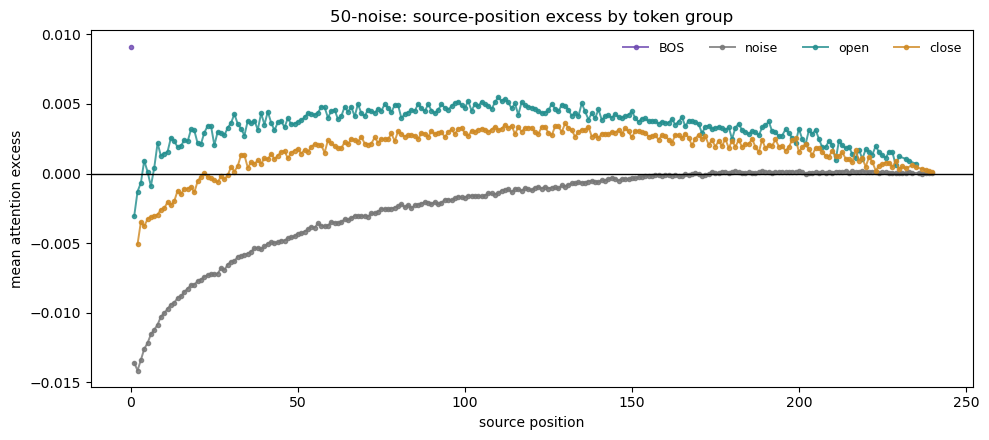

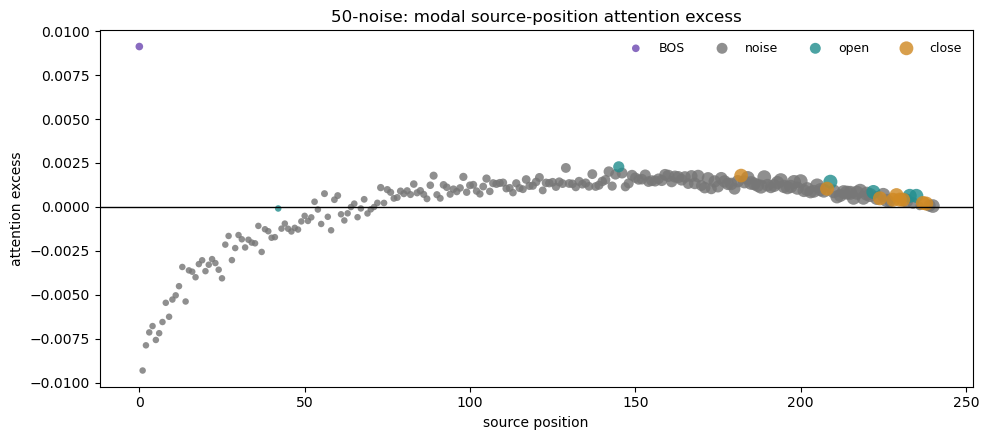

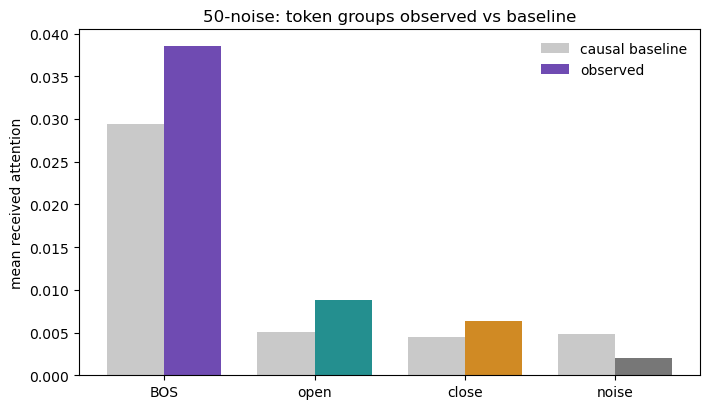

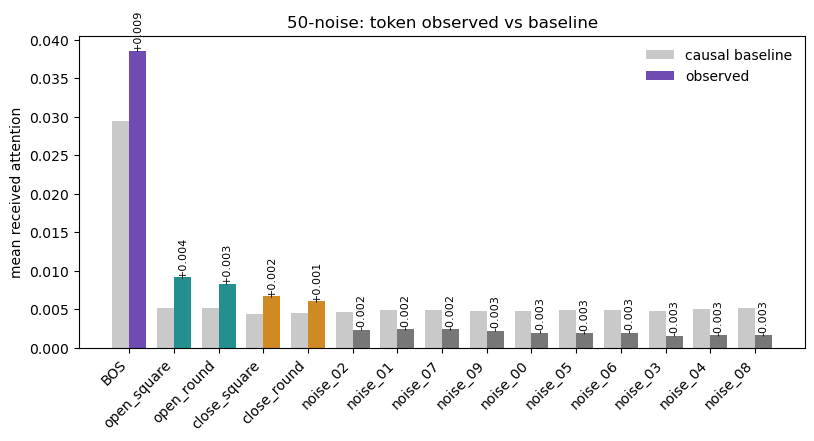

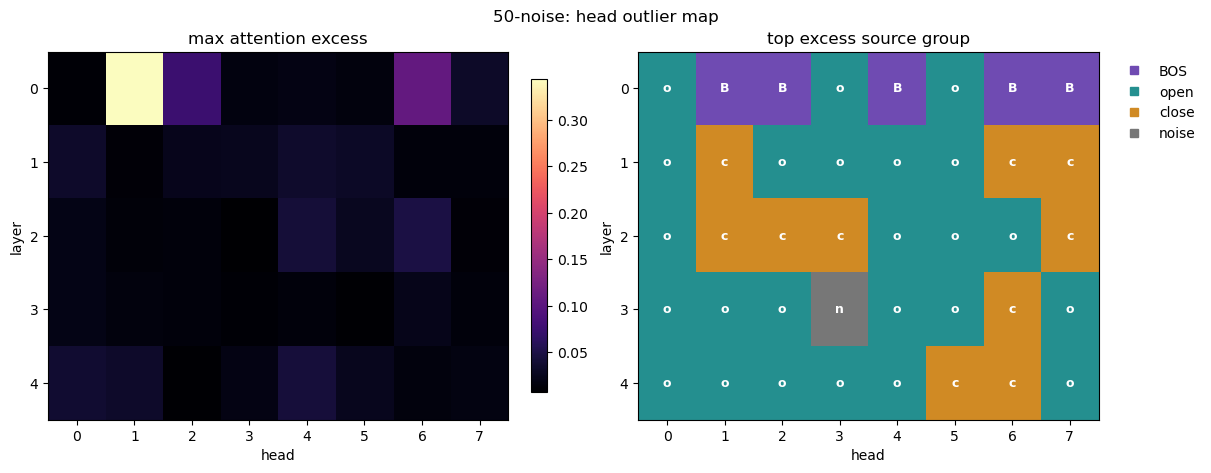

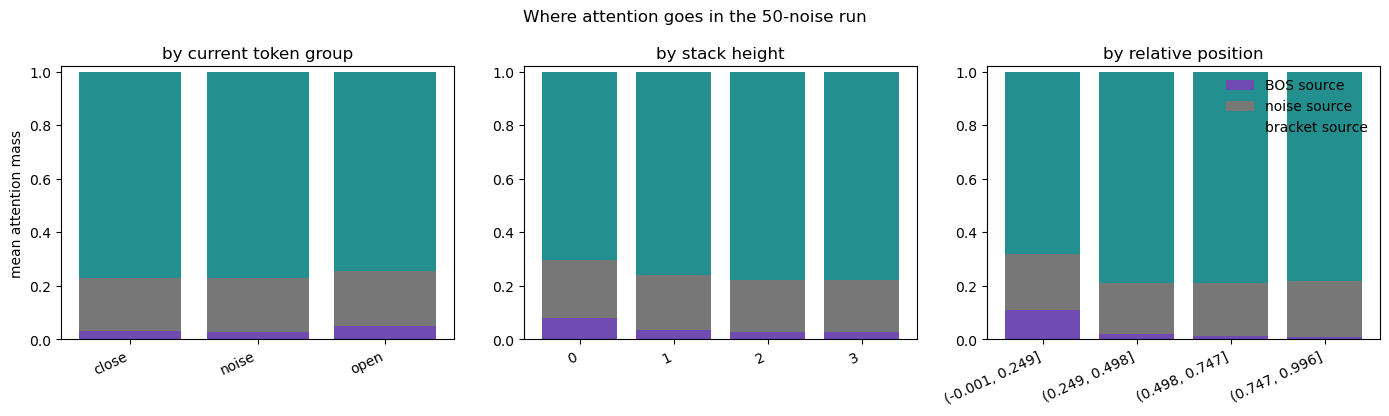

extra attention figures saved under /home/hp_twist_shan/Research/Hidden State Evaluation/results/dyck23_cfg_next_token_50_noise_len_80_120/attention/transformer_seed50025_n64/figures


In [16]:
ATTENTION_GROUP_COLORS = {
    'BOS': '#6f4bb2',
    'open': '#248f8f',
    'close': '#d08a24',
    'noise': '#777777',
    'EOS': '#b54b5a',
    'other': '#aaaaaa',
}


def infer_attention_group(name):
    name = str(name)
    if name == 'BOS':
        return 'BOS'
    if name == 'EOS':
        return 'EOS'
    if name.startswith('open_'):
        return 'open'
    if name.startswith('close_'):
        return 'close'
    if name.startswith('noise_'):
        return 'noise'
    return 'other'


def plot_source_excess_by_position_grouped(source_df, figures_root, title):
    data = source_df.copy()
    if 'token_group' not in data:
        data['token_group'] = data['token_name'].map(infer_attention_group)
    grouped = data.groupby(['source_position', 'token_group'], as_index=False).agg(
        n=('excess_mass', 'size'),
        observed=('observed_mass', 'mean'),
        baseline=('uniform_baseline_mass', 'mean'),
        excess=('excess_mass', 'mean'),
        sink_ratio=('sink_ratio', 'mean'),
    )
    fig, ax = plt.subplots(figsize=(10, 4.5))
    for group, sub in grouped.groupby('token_group', sort=False):
        sub = sub.sort_values('source_position')
        ax.plot(
            sub['source_position'],
            sub['excess'],
            marker='o',
            markersize=3,
            linewidth=1.4,
            alpha=0.82,
            color=ATTENTION_GROUP_COLORS.get(group, ATTENTION_GROUP_COLORS['other']),
            label=group,
        )
    ax.axhline(0, color='black', linewidth=1)
    ax.set_xlabel('source position')
    ax.set_ylabel('mean attention excess')
    ax.set_title(title)
    ax.legend(ncol=4, fontsize=9, frameon=False)
    fig.tight_layout()
    fig.savefig(figures_root / 'source_excess_by_position_grouped.png', dpi=180)
    plt.show()
    plt.close(fig)
    grouped.to_csv(ATTENTION_ROOT / 'source_position_group_summary.csv', index=False)
    return grouped


def plot_source_excess_by_position_colored(position_df, figures_root, title):
    data = position_df.copy()
    if 'token_group' not in data:
        data['token_group'] = data['token_name'].map(infer_attention_group)
    fig, ax = plt.subplots(figsize=(10, 4.5))
    for group, sub in data.groupby('token_group', sort=False):
        ax.scatter(
            sub['source_position'],
            sub['excess'],
            s=22 + 80 * np.clip(sub['sink_ratio'] - 1.0, 0, 3) / 3,
            color=ATTENTION_GROUP_COLORS.get(group, ATTENTION_GROUP_COLORS['other']),
            alpha=0.82,
            label=group,
            edgecolors='none',
        )
    ax.axhline(0, color='black', linewidth=1)
    ax.set_xlabel('source position')
    ax.set_ylabel('attention excess')
    ax.set_title(title)
    ax.legend(ncol=4, fontsize=9, frameon=False)
    fig.tight_layout()
    fig.savefig(figures_root / 'source_excess_by_position_colored.png', dpi=180)
    plt.show()
    plt.close(fig)


def plot_token_group_observed_vs_baseline(group_df, figures_root, title):
    data = group_df.sort_values('excess', ascending=False).copy()
    x = np.arange(len(data))
    width = 0.38
    fig, ax = plt.subplots(figsize=(7.2, 4.2))
    ax.bar(x - width / 2, data['baseline'], width, label='causal baseline', color='#c9c9c9')
    ax.bar(
        x + width / 2,
        data['observed'],
        width,
        label='observed',
        color=[ATTENTION_GROUP_COLORS.get(g, ATTENTION_GROUP_COLORS['other']) for g in data['token_group']],
    )
    ax.set_xticks(x)
    ax.set_xticklabels(data['token_group'])
    ax.set_ylabel('mean received attention')
    ax.set_title(title)
    ax.legend(frameon=False)
    fig.tight_layout()
    fig.savefig(figures_root / 'token_group_observed_vs_baseline.png', dpi=180)
    plt.show()
    plt.close(fig)


def plot_token_observed_vs_baseline(token_df, figures_root, title, max_tokens=18):
    data = token_df.copy()
    if 'token_group' not in data:
        data['token_group'] = data['token_name'].map(infer_attention_group)
    data = data.sort_values('excess', ascending=False).head(max_tokens)
    x = np.arange(len(data))
    width = 0.38
    fig, ax = plt.subplots(figsize=(max(8, len(data) * 0.55), 4.5))
    ax.bar(x - width / 2, data['baseline'], width, label='causal baseline', color='#c9c9c9')
    bars = ax.bar(
        x + width / 2,
        data['observed'],
        width,
        label='observed',
        color=[ATTENTION_GROUP_COLORS.get(g, ATTENTION_GROUP_COLORS['other']) for g in data['token_group']],
    )
    for bar, excess in zip(bars, data['excess']):
        ax.text(
            bar.get_x() + bar.get_width() / 2,
            bar.get_height(),
            f'{excess:+.3f}',
            ha='center',
            va='bottom',
            fontsize=8,
            rotation=90,
        )
    ax.set_xticks(x)
    ax.set_xticklabels(data['token_name'], rotation=45, ha='right')
    ax.set_ylabel('mean received attention')
    ax.set_title(title)
    ax.legend(frameon=False)
    fig.tight_layout()
    fig.savefig(figures_root / 'token_observed_vs_baseline.png', dpi=180)
    plt.show()
    plt.close(fig)


def plot_head_excess_and_top_group(head_df, figures_root, title):
    data = head_df.copy()
    if 'excess_top_group' not in data:
        data['excess_top_group'] = data['excess_top_token'].map(infer_attention_group)
    heat = data.pivot(index='layer', columns='head', values='max_excess_mean').sort_index()
    group = data.pivot(index='layer', columns='head', values='excess_top_group').loc[heat.index, heat.columns]
    group_order = ['BOS', 'open', 'close', 'noise', 'EOS', 'other']
    group_to_idx = {name: idx for idx, name in enumerate(group_order)}
    group_idx = group.map(lambda x: group_to_idx.get(x, group_to_idx['other']))
    cmap = plt.matplotlib.colors.ListedColormap([ATTENTION_GROUP_COLORS[g] for g in group_order])

    fig, axes = plt.subplots(1, 2, figsize=(12, 4.4), constrained_layout=True)
    im0 = axes[0].imshow(heat.to_numpy(), aspect='auto', cmap='magma')
    axes[0].set_title('max attention excess')
    axes[0].set_xlabel('head')
    axes[0].set_ylabel('layer')
    axes[0].set_xticks(range(heat.shape[1]))
    axes[0].set_xticklabels(heat.columns)
    axes[0].set_yticks(range(heat.shape[0]))
    axes[0].set_yticklabels(heat.index)
    fig.colorbar(im0, ax=axes[0], shrink=0.85)

    axes[1].imshow(group_idx.to_numpy(), aspect='auto', cmap=cmap, vmin=-0.5, vmax=len(group_order) - 0.5)
    axes[1].set_title('top excess source group')
    axes[1].set_xlabel('head')
    axes[1].set_ylabel('layer')
    axes[1].set_xticks(range(group.shape[1]))
    axes[1].set_xticklabels(group.columns)
    axes[1].set_yticks(range(group.shape[0]))
    axes[1].set_yticklabels(group.index)
    for i in range(group.shape[0]):
        for j in range(group.shape[1]):
            label = str(group.iat[i, j])
            axes[1].text(j, i, label[:1], ha='center', va='center', color='white', fontsize=9, fontweight='bold')
    handles = [
        plt.Line2D([0], [0], marker='s', linestyle='', color=ATTENTION_GROUP_COLORS[g], label=g)
        for g in group_order
        if g in set(group.to_numpy().ravel())
    ]
    axes[1].legend(handles=handles, loc='upper left', bbox_to_anchor=(1.02, 1.0), frameon=False)
    fig.suptitle(title, y=1.04)
    fig.savefig(figures_root / 'head_excess_and_top_group.png', dpi=180, bbox_inches='tight')
    plt.show()
    plt.close(fig)


def plot_noise_query_source_stacks(query_group_df, query_height_df, query_position_df, figures_root):
    def stacked(ax, data, x_col, title):
        data = data.copy()
        if x_col == 'query_token_group':
            data = data[data[x_col] != 'BOS']
        x = np.arange(len(data))
        bottom = np.zeros(len(data))
        for col, label, color in [
            ('bos_mass', 'BOS source', ATTENTION_GROUP_COLORS['BOS']),
            ('noise_source_mass', 'noise source', ATTENTION_GROUP_COLORS['noise']),
            ('bracket_source_mass', 'bracket source', ATTENTION_GROUP_COLORS['open']),
        ]:
            ax.bar(x, data[col], bottom=bottom, label=label, color=color)
            bottom += data[col].to_numpy()
        ax.set_xticks(x)
        ax.set_xticklabels(data[x_col].astype(str), rotation=25, ha='right')
        ax.set_ylim(0, 1.02)
        ax.set_title(title)

    fig, axes = plt.subplots(1, 3, figsize=(14, 4.2))
    stacked(axes[0], query_group_df, 'query_token_group', 'by current token group')
    stacked(axes[1], query_height_df, 'height', 'by stack height')
    stacked(axes[2], query_position_df, 'pos_bin', 'by relative position')
    axes[0].set_ylabel('mean attention mass')
    axes[2].legend(loc='upper right', frameon=False)
    fig.suptitle('Where attention goes in the 50-noise run')
    fig.tight_layout()
    fig.savefig(figures_root / 'query_source_mass_stacked.png', dpi=180)
    plt.show()
    plt.close(fig)

attention_source_rows_df = pd.read_csv(ATTENTION_ROOT / 'source_attention_rows.csv')
attention_source_position_group_df = plot_source_excess_by_position_grouped(
    attention_source_rows_df,
    ATTENTION_FIGURES_ROOT,
    '50-noise: source-position excess by token group',
)
plot_source_excess_by_position_colored(
    attention_position_summary_df,
    ATTENTION_FIGURES_ROOT,
    '50-noise: modal source-position attention excess',
)
plot_token_group_observed_vs_baseline(
    attention_group_summary_df,
    ATTENTION_FIGURES_ROOT,
    '50-noise: token groups observed vs baseline',
)
plot_token_observed_vs_baseline(
    attention_token_summary_df,
    ATTENTION_FIGURES_ROOT,
    '50-noise: token observed vs baseline',
    max_tokens=20,
)
plot_head_excess_and_top_group(
    attention_head_summary_df,
    ATTENTION_FIGURES_ROOT,
    '50-noise: head outlier map',
)
plot_noise_query_source_stacks(
    attention_query_group_summary_df,
    attention_query_height_summary_df,
    attention_query_position_bin_summary_df,
    ATTENTION_FIGURES_ROOT,
)

print(f'extra attention figures saved under {ATTENTION_FIGURES_ROOT}')